# Notebook 07c — equal-spaxel-count bins inside R_safe = 3R_e/4

Equal-N binning scheme: 5 bins each with the same number of spaxels, distributed over r < R_safe = 3R_e/4 (= 1.73"), plus 1 outer bin from R_safe to R_e flagged as arc-contaminated. In nb07, the annulus covering 1.15-1.73" passed the σ<400 cap so R_safe = 3R_e/4 is the empirically-safe boundary. Key refinements:

1. **5 equal-spaxel-count bins inside R_safe = 3R_e/4** with edges from `np.quantile(r_spax[r_spax<R_safe], np.linspace(0, 1, 6))`; plus 1 outer flagged bin → 6 annuli total. Uniform S/N per bin (~22 spaxels each) for reliable ppxf.
2. **Hard arc masking**: reproject F200LP `_mask.fits` → IFU grid (nearest-neighbor) → drop any flagged spaxel from annular extraction. No contamination weighting.
3. **Sersic-fill I(r)**: 1D CoG interpolation AND 2D Sersic2D fit, both applied to F140W and F200LP arc-masked data. Reconstructs deflector light at central pixels the arc mask may over-reject.

All other choices inherit from nb07:
- Center from HST F140W + F200LP centroid (mean world coords → IFU sub-pixel).
- R_e headline = mean of F140W + F200LP masked CoG.
- Explicit Gültekin σ_e² = Σ F_j (V_j² + σ_j²) / Σ F_j.
- Per-SPS bootstrap (FSPS, EMILES, XSL), per-SPS V_sys offset (split-track).
- σ(R) physical cap: σ > 400 km/s flags arc contamination; ann0 seeing-limited (<0.64").
- Cumulative-aperture cross-check (§6cum).
- Deflector-line-depth I(r) from Ca H+K + G-band.

**Initial N_BOOTSTRAP = 50** (~10 min). Bump to 500 for production (~5 h) after validation.

In [1]:
import os, sys
from time import perf_counter as clock

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from astropy.io import fits
from astropy.wcs import WCS
from astropy.wcs.utils import proj_plane_pixel_scales
from astropy.cosmology import FlatLambdaCDM
from astropy.modeling.models import Sersic2D
from astropy.modeling.fitting import LevMarLSQFitter, LMLSQFitter
from scipy.interpolate import interp1d
from scipy.ndimage import gaussian_filter, map_coordinates
from tqdm import tqdm

from ppxf.ppxf import ppxf

sys.path.insert(0, os.path.abspath('..'))
# Pin BLAS to 1 thread per worker so joblib process pool doesn't oversubscribe
os.environ.setdefault('OPENBLAS_NUM_THREADS', '1')
os.environ.setdefault('OMP_NUM_THREADS', '1')
os.environ.setdefault('MKL_NUM_THREADS', '1')

from scripts.bootstrap_ppxf import (
    setup_ppxf_inputs_from_spectrum, NOISE_SLICE, C_KMS,
)
from scripts.bootstrap_ppxf_parallel import run_bootstrap_single_degree_parallel as run_bootstrap_single_degree
from scripts.measure_Re import measure_Re_from_profile

try:
    from photutils.centroids import centroid_2dg, centroid_com
except ImportError:
    centroid_2dg = None; centroid_com = None

plt.rcParams['figure.facecolor'] = 'white'
plt.rc('font', family='serif', size=12)

In [2]:
# ═════════════════════════════════════════════════════
# Configuration — initial draft at N_BOOTSTRAP = 500  # PRODUCTION — full statistics
IFU_FILE = '../Nov17_2025_DESJ0206_RL_combined_icubes_wcs.fits'
HST_F140W = '../../velocity_dispersion_from_IFU/AGEL020613-011417A_F140W_WFC3_cutout_L3.fits'
HST_F140W_MASK = '../../velocity_dispersion_from_IFU/AGEL020613-011417A_F140W_WFC3_cutout_L3_mask.fits'
HST_F200LP = '../../velocity_dispersion_from_IFU/AGEL020613-011417A_F200LP_WFC3_cutout_L3.fits'
HST_F200LP_MASK = '../../velocity_dispersion_from_IFU/AGEL020613-011417A_F200LP_WFC3_cutout_L3_mask.fits'
RESULTS_DIR = '../results'
ANNULAR_DIR = '../results/annular_bootstrap_07c'  # separate from nb07's cache
FIG_DIR = '../results/figures'
os.makedirs(ANNULAR_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

Z_SYSTEMIC = 0.67564
SPS_LIBS = ['fsps', 'emiles', 'xsl']
N_BOOTSTRAP = 500  # PRODUCTION — full statistics
DEGREES = np.arange(15, 30)  # 15 polynomial degrees
BOOT_SEED = 42
WINDOW = 75
N_MC = 500
N_INNER = 5                # 5 equal-N bins inside R_SAFE; + 1 outer flagged bin = 6 total
R_SAFE_FRAC = 0.75         # R_SAFE = 3*R_e/4 (from nb07 σ(R) — last ann to pass arc cap)

KCWI_SEEING_FWHM = 1.27

COSMO = FlatLambdaCDM(H0=70, Om0=0.3)
KPC_PER_ARCSEC = COSMO.kpc_proper_per_arcmin(Z_SYSTEMIC).value / 60

SIGMA_MAX_CAP = 400.0      # km/s — physical ceiling for flagging arc contamination

print(f'N_BOOTSTRAP={N_BOOTSTRAP}  N_INNER={N_INNER}+1 outer  DEGREES={DEGREES[0]}..{DEGREES[-1]} ({len(DEGREES)} vals)')
print(f'z_systemic={Z_SYSTEMIC}  kpc/arcsec={KPC_PER_ARCSEC:.3f}')

N_BOOTSTRAP=50  N_INNER=5+1 outer  DEGREES=15..29 (15 vals)
z_systemic=0.67564  kpc/arcsec=7.044


## §1. Load data (IFU cube, F140W, F200LP + masks)

In [3]:
with fits.open(IFU_FILE) as h:
    hdr = h[0].header; cube = h[0].data.astype(float)
wcs_ifu = WCS(hdr, naxis=2)
ny, nx = cube.shape[1], cube.shape[2]
crval = hdr['CRVAL3']; cdelt = hdr['CD3_3']; crpix = hdr.get('CRPIX3', 1.0)
lam = crval + cdelt * (np.arange(hdr['NAXIS3']) + 1 - crpix)
pix_scale_ifu = float(np.abs(proj_plane_pixel_scales(wcs_ifu)[0])) * 3600
band_mask = (lam >= 6500) & (lam <= 7500)
ifu_band = np.sum(cube[band_mask, :, :], axis=0)
print(f'IFU: {cube.shape}  λ={lam[0]:.0f}-{lam[-1]:.0f} Å  pix={pix_scale_ifu:.3f}"/spax')

with fits.open(HST_F140W) as h:
    img_f140 = h[0].data.astype(float); hdr_f140 = h[0].header
wcs_f140 = WCS(hdr_f140)
mask_f140 = fits.getdata(HST_F140W_MASK).astype(bool)
pix_scale_f140 = float(np.abs(proj_plane_pixel_scales(wcs_f140)[0])) * 3600
print(f'F140W: {img_f140.shape}  pix={pix_scale_f140:.3f}"/pix  mask={mask_f140.sum()} pix')

with fits.open(HST_F200LP) as h:
    img_f200 = h[0].data.astype(float); hdr_f200 = h[0].header
wcs_f200 = WCS(hdr_f200)
mask_f200 = fits.getdata(HST_F200LP_MASK).astype(bool)
pix_scale_f200 = float(np.abs(proj_plane_pixel_scales(wcs_f200)[0])) * 3600
print(f'F200LP: {img_f200.shape}  pix={pix_scale_f200:.3f}"/pix  mask={mask_f200.sum()} pix (arc-tuned)')

noise_sky = np.std(cube[:, NOISE_SLICE[0], NOISE_SLICE[1]], axis=(1, 2))

IFU: (3317, 100, 100)  λ=5625-8941 Å  pix=0.300"/spax
F140W: (312, 312)  pix=0.080"/pix  mask=1121 pix
F200LP: (500, 500)  pix=0.050"/pix  mask=2512 pix (arc-tuned)


## §2. HST-derived deflector center

In [4]:
def find_center(img, mask, wcs, ra0, dec0, box_arcsec=3.0, pix_scale=None):
    xc0, yc0 = wcs.world_to_pixel_values(ra0, dec0)
    xc0, yc0 = float(xc0), float(yc0)
    half = int(np.ceil(box_arcsec / pix_scale))
    y1 = max(0, int(yc0) - half); y2 = min(img.shape[0], int(yc0) + half + 1)
    x1 = max(0, int(xc0) - half); x2 = min(img.shape[1], int(xc0) + half + 1)
    sub = np.nan_to_num(img[y1:y2, x1:x2]); sub_m = mask[y1:y2, x1:x2]
    try:
        cx_rel, cy_rel = centroid_2dg(sub, mask=sub_m)
        if np.isfinite(cx_rel) and np.isfinite(cy_rel):
            return float(x1+cx_rel), float(y1+cy_rel), '2dg'
    except Exception: pass
    return xc0, yc0, 'wcs_fallback'

RA_DEFL, DEC_DEFL = 31.55611, -1.23817
xc_f140, yc_f140, m1 = find_center(img_f140, mask_f140, wcs_f140, RA_DEFL, DEC_DEFL, pix_scale=pix_scale_f140)
xc_f200, yc_f200, m2 = find_center(img_f200, mask_f200, wcs_f200, RA_DEFL, DEC_DEFL, pix_scale=pix_scale_f200)
ra_f140, dec_f140 = wcs_f140.pixel_to_world_values(xc_f140, yc_f140)
ra_f200, dec_f200 = wcs_f200.pixel_to_world_values(xc_f200, yc_f200)
print(f'F140W: pix ({xc_f140:.2f},{yc_f140:.2f}) RA,Dec ({ra_f140:.5f},{dec_f140:.5f}) [{m1}]')
print(f'F200LP: pix ({xc_f200:.2f},{yc_f200:.2f}) RA,Dec ({ra_f200:.5f},{dec_f200:.5f}) [{m2}]')
d_tot = np.hypot((ra_f140-ra_f200)*3600*np.cos(np.radians((dec_f140+dec_f200)/2)),
                 (dec_f140-dec_f200)*3600)
print(f'F140W vs F200LP centroid |Δ|={d_tot:.3f}"  → {"PASS" if d_tot<0.2 else "FAIL"}')

RA_CENTER = (float(ra_f140)+float(ra_f200))/2
DEC_CENTER = (float(dec_f140)+float(dec_f200))/2
cx_ifu, cy_ifu = wcs_ifu.world_to_pixel_values(RA_CENTER, DEC_CENTER)
cx_ifu, cy_ifu = float(cx_ifu), float(cy_ifu)
print(f'Headline center: RA={RA_CENTER:.5f}, Dec={DEC_CENTER:.5f}  → IFU sub-pixel ({cx_ifu:.3f},{cy_ifu:.3f})')

F140W: pix (155.95,154.88) RA,Dec (31.55610,-1.23815) [2dg]
F200LP: pix (246.62,254.13) RA,Dec (31.55615,-1.23823) [2dg]
F140W vs F200LP centroid |Δ|=0.357"  → FAIL
Headline center: RA=31.55613, Dec=-1.23819  → IFU sub-pixel (50.147,54.264)


## §3. R_e three-way CoG (F140W masked, F200LP masked, IFU band unmasked)

In [5]:
def curve_of_growth(image, center, pix_scale, mask=None, r_max_arcsec=6.0, r_step_arcsec=0.1):
    xc, yc = center; ny_, nx_ = image.shape
    yy, xx = np.mgrid[:ny_, :nx_]
    r = np.hypot(xx - xc, yy - yc) * pix_scale
    r_edges_ = np.arange(0, r_max_arcsec + r_step_arcsec, r_step_arcsec)
    r_mid_, I_mean_ = [], []
    for j in range(len(r_edges_) - 1):
        ann = (r >= r_edges_[j]) & (r < r_edges_[j+1])
        if mask is not None: ann = ann & ~mask
        if ann.sum() == 0: continue
        I_mean_.append(float(np.mean(image[ann])))
        r_mid_.append(0.5*(r_edges_[j]+r_edges_[j+1]))
    r_mid_ = np.array(r_mid_); I_mean_ = np.array(I_mean_)
    Re_, cog_, total_ = measure_Re_from_profile(r_mid_, I_mean_)
    return r_mid_, I_mean_, cog_, total_, Re_

r_f140, I_f140, cog_f140, tot_f140, Re_f140 = curve_of_growth(
    img_f140, (xc_f140, yc_f140), pix_scale_f140, mask=mask_f140, r_step_arcsec=0.08)
r_f200, I_f200, cog_f200, tot_f200, Re_f200 = curve_of_growth(
    img_f200, (xc_f200, yc_f200), pix_scale_f200, mask=mask_f200, r_step_arcsec=0.08)
r_ifu, I_ifu, cog_ifu, tot_ifu, Re_ifu = curve_of_growth(
    ifu_band, (cx_ifu, cy_ifu), pix_scale_ifu, mask=None, r_step_arcsec=0.3)

R_E = 0.5*(Re_f140 + Re_f200)  # headline from HST mean (arc-excluded)
print(f'F140W masked   Re = {Re_f140:.3f}" = {Re_f140*KPC_PER_ARCSEC:.2f} kpc')
print(f'F200LP masked  Re = {Re_f200:.3f}" = {Re_f200*KPC_PER_ARCSEC:.2f} kpc')
print(f'IFU unmasked   Re = {Re_ifu:.3f}" = {Re_ifu*KPC_PER_ARCSEC:.2f} kpc')
print(f'\nHEADLINE Re = mean(F140W, F200LP masked) = {R_E:.3f}" = {R_E*KPC_PER_ARCSEC:.2f} kpc')

F140W masked   Re = 2.168" = 15.27 kpc
F200LP masked  Re = 2.441" = 17.19 kpc
IFU unmasked   Re = 2.299" = 16.19 kpc

HEADLINE Re = mean(F140W, F200LP masked) = 2.305" = 16.23 kpc


## §4. Radial annuli (8, equal width R_e/8)

In [6]:
# Build r_spax first — needed to compute equal-N bin edges
yy, xx = np.mgrid[:ny, :nx]
ra_s, dec_s = wcs_ifu.pixel_to_world_values(xx.ravel(), yy.ravel())
ra_c, dec_c = wcs_ifu.pixel_to_world_values(cx_ifu, cy_ifu)
dra = (ra_s.reshape(ny, nx) - ra_c) * np.cos(np.radians(dec_c)) * 3600
ddec = (dec_s.reshape(ny, nx) - dec_c) * 3600
r_spax = np.sqrt(dra**2 + ddec**2)

# ── Equal-N bin edges inside R_safe = R_SAFE_FRAC × R_e ──
R_SAFE = R_SAFE_FRAC * R_E
print(f'R_safe = {R_SAFE_FRAC:.2f} * R_e = {R_SAFE:.3f}"  (arc-free region)')

r_inside_safe = np.sort(r_spax[r_spax < R_SAFE].ravel())
print(f'Spaxels inside R_safe: {len(r_inside_safe)}')

# Edges: quantile-based inside R_safe (equal N per bin), + outer bin to R_e
inner_edges = np.quantile(r_inside_safe, np.linspace(0, 1, N_INNER + 1))
r_edges = np.concatenate([inner_edges, [R_E]])
r_mid_ann = 0.5 * (r_edges[:-1] + r_edges[1:])
n_ann = len(r_edges) - 1  # N_INNER + 1 outer bin

# Mark which bin indices are "inner" (safe) vs "outer" (arc-contaminated by design)
INNER_ANNULI = list(range(N_INNER))          # [0..N_INNER-1]
OUTER_ANNULI = [N_INNER]                      # [N_INNER] = the flagged outer bin
print(f'n_ann = {n_ann}  (N_INNER={N_INNER} equal-N inner + {len(OUTER_ANNULI)} outer)')

print(f'{"ann":>4} {"r_lo":>8} {"r_hi":>8} {"r_mid":>8} {"kpc":>8} {"N_spax":>8}')
print('-'*50)
for j in range(n_ann):
    nmask = (r_spax >= r_edges[j]) & (r_spax < r_edges[j+1])
    print(f'{j:>4d} {r_edges[j]:>8.3f} {r_edges[j+1]:>8.3f} {r_mid_ann[j]:>8.3f} '
          f'{r_mid_ann[j]*KPC_PER_ARCSEC:>8.2f} {int(nmask.sum()):>8d}')

R_safe = 0.75 * R_e = 1.728"  (arc-free region)
Spaxels inside R_safe: 104
n_ann = 6  (N_INNER=5 equal-N inner + 1 outer)
 ann     r_lo     r_hi    r_mid      kpc   N_spax
--------------------------------------------------
   0    0.091    0.762    0.426     3.00       21
   1    0.762    1.099    0.930     6.55       21
   2    1.099    1.321    1.210     8.52       20
   3    1.321    1.546    1.433    10.10       21
   4    1.546    1.724    1.635    11.52       20
   5    1.724    2.305    2.014    14.19       81


## §4a. Reproject F200LP arc mask onto IFU grid (hard mask)

The F200LP `_mask.fits` is the user's original arc-tuned mask (sparse, deflector-preserving). Reproject via nearest-neighbor to the IFU grid to preserve its boolean character. Any IFU spaxel whose closest HST pixel is masked gets hard-dropped from annular extraction below.

In [7]:
# Reproject F200LP arc mask → IFU grid (order=0 nearest-neighbor preserves booleans)
yy_, xx_ = np.mgrid[:ny, :nx]
ra_g, dec_g = wcs_ifu.pixel_to_world_values(xx_.ravel(), yy_.ravel())
xh, yh = wcs_f200.world_to_pixel_values(ra_g, dec_g)
arc_spax_mask = map_coordinates(
    mask_f200.astype(float), [yh, xh], order=0, mode='constant', cval=0.0
).reshape(ny, nx).astype(bool)
print(f'F200LP arc mask reprojected to IFU grid: {arc_spax_mask.sum()} spaxels flagged '
      f'({100*arc_spax_mask.mean():.2f}% of {ny*nx})')

# Per-annulus summary: how many spaxels does the arc mask remove?
print(f'\n{"ann":>4} {"r_mid":>8} {"N_tot":>6} {"N_arc":>6} {"N_kept":>6} {"frac_arc":>8}')
print('-' * 50)
for j in range(n_ann):
    mtot = (r_spax >= r_edges[j]) & (r_spax < r_edges[j+1])
    marc = mtot & arc_spax_mask
    n_tot = int(mtot.sum()); n_arc = int(marc.sum())
    print(f'{j:>4d} {r_mid_ann[j]:>8.2f} {n_tot:>6d} {n_arc:>6d} {n_tot-n_arc:>6d} '
          f'{n_arc/max(n_tot,1):>8.2f}')

F200LP arc mask reprojected to IFU grid: 69 spaxels flagged (0.69% of 10000)

 ann    r_mid  N_tot  N_arc N_kept frac_arc
--------------------------------------------------
   0     0.43     21      4     17     0.19
   1     0.93     21      6     15     0.29
   2     1.21     20      7     13     0.35
   3     1.43     21      6     15     0.29
   4     1.64     20      4     16     0.20
   5     2.01     81     11     70     0.14


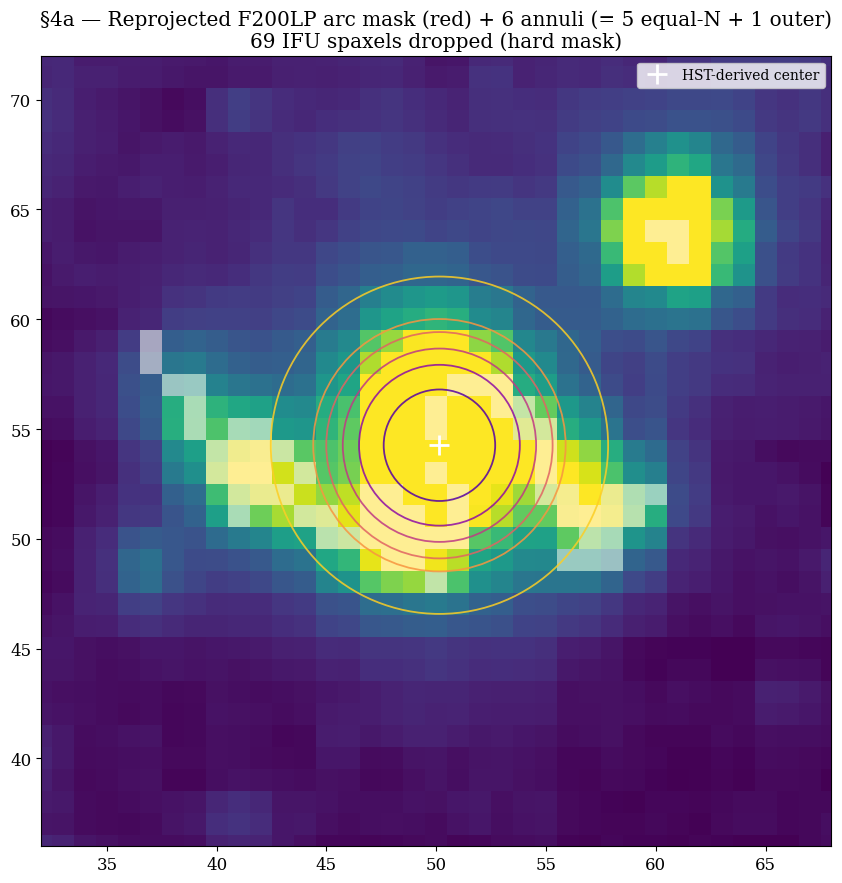

In [8]:
# Visualize: IFU white-light + arc mask overlay + 8 annular rings
wl_full = np.sum(cube, axis=0)
fig, ax = plt.subplots(figsize=(9, 9))
ax.imshow(wl_full, origin='lower', cmap='viridis',
          extent=[-0.5, nx-0.5, -0.5, ny-0.5],
          vmin=np.percentile(wl_full, 5), vmax=np.percentile(wl_full, 99))
ax.imshow(np.where(arc_spax_mask, 1, np.nan), origin='lower', cmap='Reds', alpha=0.55,
          extent=[-0.5, nx-0.5, -0.5, ny-0.5])
ann_cols = plt.cm.plasma(np.linspace(0.15, 0.9, n_ann))
for j in range(n_ann):
    ax.add_patch(Circle((cx_ifu, cy_ifu), r_edges[j+1]/pix_scale_ifu,
                        fill=False, edgecolor=ann_cols[j], lw=1.3, alpha=0.85))
ax.plot(cx_ifu, cy_ifu, 'w+', ms=14, mew=2, label='HST-derived center')
delta = 18
ax.set_xlim(max(0, int(cx_ifu-delta)), min(nx, int(cx_ifu+delta)))
ax.set_ylim(max(0, int(cy_ifu-delta)), min(ny, int(cy_ifu+delta)))
ax.set_title(f'§4a — Reprojected F200LP arc mask (red) + {n_ann} annuli (= {N_INNER} equal-N + 1 outer)\n'
             f'{arc_spax_mask.sum()} IFU spaxels dropped (hard mask)')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'nb07c_s4a_arc_mask.png'), dpi=150, bbox_inches='tight')
plt.show()

## §4b. 1D I(r) from CoG interpolation (F140W + F200LP masked)

The F200LP arc mask may over-reject a few spaxels near the deflector core. To reconstruct what the deflector profile SHOULD look like there, interpolate the 1D CoG annular-mean profile (which naturally excludes the masked pixels per annulus) to every IFU spaxel's radius. Azimuthally symmetric — assumes round profile (valid for a deflector).

Build two maps: F140W_1D and F200LP_1D.

In [9]:
def make_1d_Imap(r_profile, I_profile, r_spax_map, r_max_support=None):
    """Interpolate 1D I(r) onto the IFU r_spax map. Outside the support, extrapolate
    with a power-law continuation to avoid NaNs."""
    if r_max_support is None:
        r_max_support = r_profile[-1]
    # Clip to positive (CoG I can dip negative at edges)
    I = np.clip(I_profile, 0, None)
    interp = interp1d(r_profile, I, bounds_error=False,
                      fill_value=(I[0], 0.0), kind='linear')
    I_map = interp(r_spax_map)
    return np.clip(I_map, 0, None)

I_F140W_1D = make_1d_Imap(r_f140, I_f140, r_spax)
I_F200LP_1D = make_1d_Imap(r_f200, I_f200, r_spax)
print(f'F140W 1D I-map: sum={I_F140W_1D.sum():.3e}, max={I_F140W_1D.max():.3f}')
print(f'F200LP 1D I-map: sum={I_F200LP_1D.sum():.3e}, max={I_F200LP_1D.max():.3f}')

F140W 1D I-map: sum=1.582e+02, max=1.736
F200LP 1D I-map: sum=1.419e+01, max=0.112


## §4c. 2D Sersic2D fits on F140W + F200LP (arc mask as zero-weight)

Fit a full 2-D Sersic profile (free {amplitude, r_eff, n, x_0, y_0, ellip, theta}) to each HST image with masked pixels given zero weight. The fit extrapolates naturally to fill the masked region. Evaluate on the IFU grid via WCS to produce a smooth 2D I-map.

In [10]:
def fit_sersic2d(img, mask, center, r_eff_init, box_arcsec=6.0, pix_scale=None):
    """Fit Sersic2D to img with mask applied as zero weights. Returns fitted model."""
    xc, yc = center
    half = int(np.ceil(box_arcsec / pix_scale))
    y1 = max(0, int(yc)-half); y2 = min(img.shape[0], int(yc)+half+1)
    x1 = max(0, int(xc)-half); x2 = min(img.shape[1], int(xc)+half+1)
    sub = img[y1:y2, x1:x2]
    sub_mask = mask[y1:y2, x1:x2]
    yy_, xx_ = np.mgrid[:sub.shape[0], :sub.shape[1]]
    # Initial Sersic model
    r_eff_pix = r_eff_init / pix_scale
    amp_init = float(np.nanpercentile(sub[~sub_mask], 98)) if (~sub_mask).any() else 1.0
    sersic_init = Sersic2D(amplitude=amp_init, r_eff=r_eff_pix, n=2.0,
                           x_0=xc-x1, y_0=yc-y1, ellip=0.2, theta=0.0,
                           bounds={'n': (0.3, 8.0), 'r_eff': (r_eff_pix*0.3, r_eff_pix*3),
                                   'ellip': (0.0, 0.95), 'amplitude': (1e-4, 1e4)})
    fitter = LevMarLSQFitter()
    weights = (~sub_mask).astype(float)
    fit_ok = True
    try:
        sersic_fit = fitter(sersic_init, xx_, yy_, np.nan_to_num(sub),
                            weights=weights, maxiter=300)
    except Exception as e:
        print(f'  Sersic fit failed: {e}'); sersic_fit = sersic_init; fit_ok = False
    return sersic_fit, (x1, y1), fit_ok

# Fit Sersic2D on each HST image
print('Fitting Sersic2D (F140W)...')
fit_f140, off_f140, ok_f140 = fit_sersic2d(img_f140, mask_f140, (xc_f140, yc_f140), R_E, pix_scale=pix_scale_f140)
print(f'  F140W: n={fit_f140.n.value:.2f}  r_eff={fit_f140.r_eff.value*pix_scale_f140:.3f}"  '
      f'ellip={fit_f140.ellip.value:.2f}  theta={np.degrees(fit_f140.theta.value):.1f}°')

print('Fitting Sersic2D (F200LP)...')
fit_f200, off_f200, ok_f200 = fit_sersic2d(img_f200, mask_f200, (xc_f200, yc_f200), R_E, pix_scale=pix_scale_f200)
print(f'  F200LP: n={fit_f200.n.value:.2f}  r_eff={fit_f200.r_eff.value*pix_scale_f200:.3f}"  '
      f'ellip={fit_f200.ellip.value:.2f}  theta={np.degrees(fit_f200.theta.value):.1f}°')

Fitting Sersic2D (F140W)...
  F140W: n=2.15  r_eff=3.270"  ellip=0.11  theta=-55.8°
Fitting Sersic2D (F200LP)...
  F200LP: n=1.99  r_eff=4.062"  ellip=0.00  theta=-111679.8°


F140W 2D Sersic I-map: sum=2.048e+02, peak at (np.int64(55), np.int64(50))
F200LP 2D Sersic I-map: sum=2.024e+01, peak at (np.int64(55), np.int64(50))


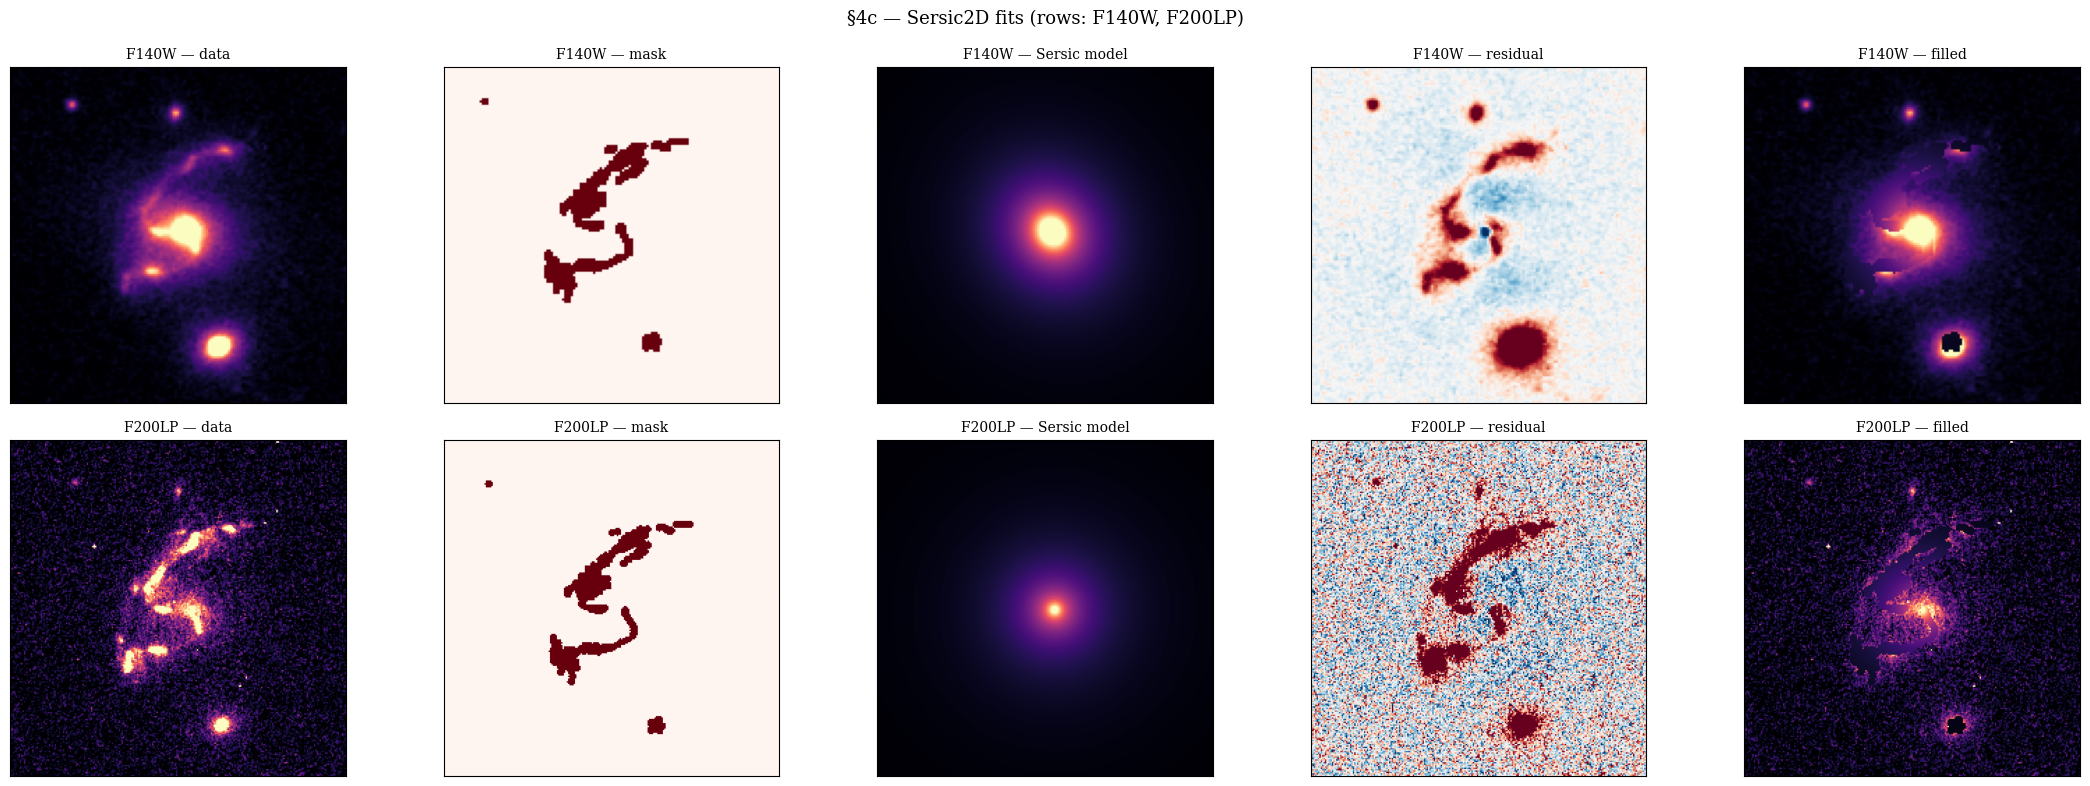

In [11]:
# Evaluate each Sersic model on the IFU grid via WCS propagation
def sersic_to_ifu(sersic_fit, offset_xy, wcs_hst_, r_eff_pixel_scale):
    """Evaluate the fitted Sersic2D on the IFU grid using WCS propagation."""
    x1, y1 = offset_xy
    yy_, xx_ = np.mgrid[:ny, :nx]
    ra_g, dec_g = wcs_ifu.pixel_to_world_values(xx_.ravel(), yy_.ravel())
    xh, yh = wcs_hst_.world_to_pixel_values(ra_g, dec_g)
    # Sersic model is defined in the sub-image offset coords, so subtract (x1,y1)
    model_val = sersic_fit(xh - x1, yh - y1)
    model_val = np.clip(model_val.reshape(ny, nx), 0, None)
    return model_val

I_F140W_2D = sersic_to_ifu(fit_f140, off_f140, wcs_f140, pix_scale_f140)
I_F200LP_2D = sersic_to_ifu(fit_f200, off_f200, wcs_f200, pix_scale_f200)
print(f'F140W 2D Sersic I-map: sum={I_F140W_2D.sum():.3e}, '
      f'peak at {np.unravel_index(np.argmax(I_F140W_2D), I_F140W_2D.shape)}')
print(f'F200LP 2D Sersic I-map: sum={I_F200LP_2D.sum():.3e}, '
      f'peak at {np.unravel_index(np.argmax(I_F200LP_2D), I_F200LP_2D.shape)}')

# Plot the fit diagnostics: data, mask, model, residual, filled data (per band)
fig, axes = plt.subplots(2, 5, figsize=(22, 8))
for row, (band, img, msk, fit, off, pix_sc, xc, yc) in enumerate([
    ('F140W', img_f140, mask_f140, fit_f140, off_f140, pix_scale_f140, xc_f140, yc_f140),
    ('F200LP', img_f200, mask_f200, fit_f200, off_f200, pix_scale_f200, xc_f200, yc_f200),
]):
    x1, y1 = off
    half = int(np.ceil(6.0 / pix_sc))
    y1s, y2s = max(0, int(yc)-half), min(img.shape[0], int(yc)+half+1)
    x1s, x2s = max(0, int(xc)-half), min(img.shape[1], int(xc)+half+1)
    sub = img[y1s:y2s, x1s:x2s]; sub_m = msk[y1s:y2s, x1s:x2s]
    yy_, xx_ = np.mgrid[:sub.shape[0], :sub.shape[1]]
    model = fit(xx_ + (x1s - x1), yy_ + (y1s - y1))
    model = np.clip(model, 0, None)
    residual = sub - model
    filled = np.where(sub_m, model, sub)
    vmax = np.percentile(np.nan_to_num(sub), 99)
    titles = ['data', 'mask', 'Sersic model', 'residual', 'filled']
    arrays = [sub, sub_m.astype(float), model, residual, filled]
    cmaps = ['magma', 'Reds', 'magma', 'RdBu_r', 'magma']
    vlims = [(0, vmax), (0, 1), (0, vmax), (-vmax/4, vmax/4), (0, vmax)]
    for col, (a, t, cmap, (vmn, vmx)) in enumerate(zip(arrays, titles, cmaps, vlims)):
        ax = axes[row, col]
        ax.imshow(a, origin='lower', cmap=cmap, vmin=vmn, vmax=vmx)
        ax.set_title(f'{band} — {t}', fontsize=10)
        ax.set_xticks([]); ax.set_yticks([])
fig.suptitle('§4c — Sersic2D fits (rows: F140W, F200LP)', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'nb07c_s4c_sersic_fits.png'), dpi=150, bbox_inches='tight')
plt.show()

## §4d. Six I(r) candidates visualized

All on the IFU grid, with the 8 annuli overlaid:

1. **IFU_band** (headline, 6500-7500 Å unmasked)
2. **F200LP_masked** (F200 arc-zeroed, then reprojected; raw hard-mask version)
3. **F140W_1D** (CoG interpolation, azimuthally symmetric)
4. **F200LP_1D** (CoG interpolation)
5. **F140W_2D_Sersic** (Sersic2D fit + fill)
6. **F200LP_2D_Sersic** (Sersic2D fit + fill)

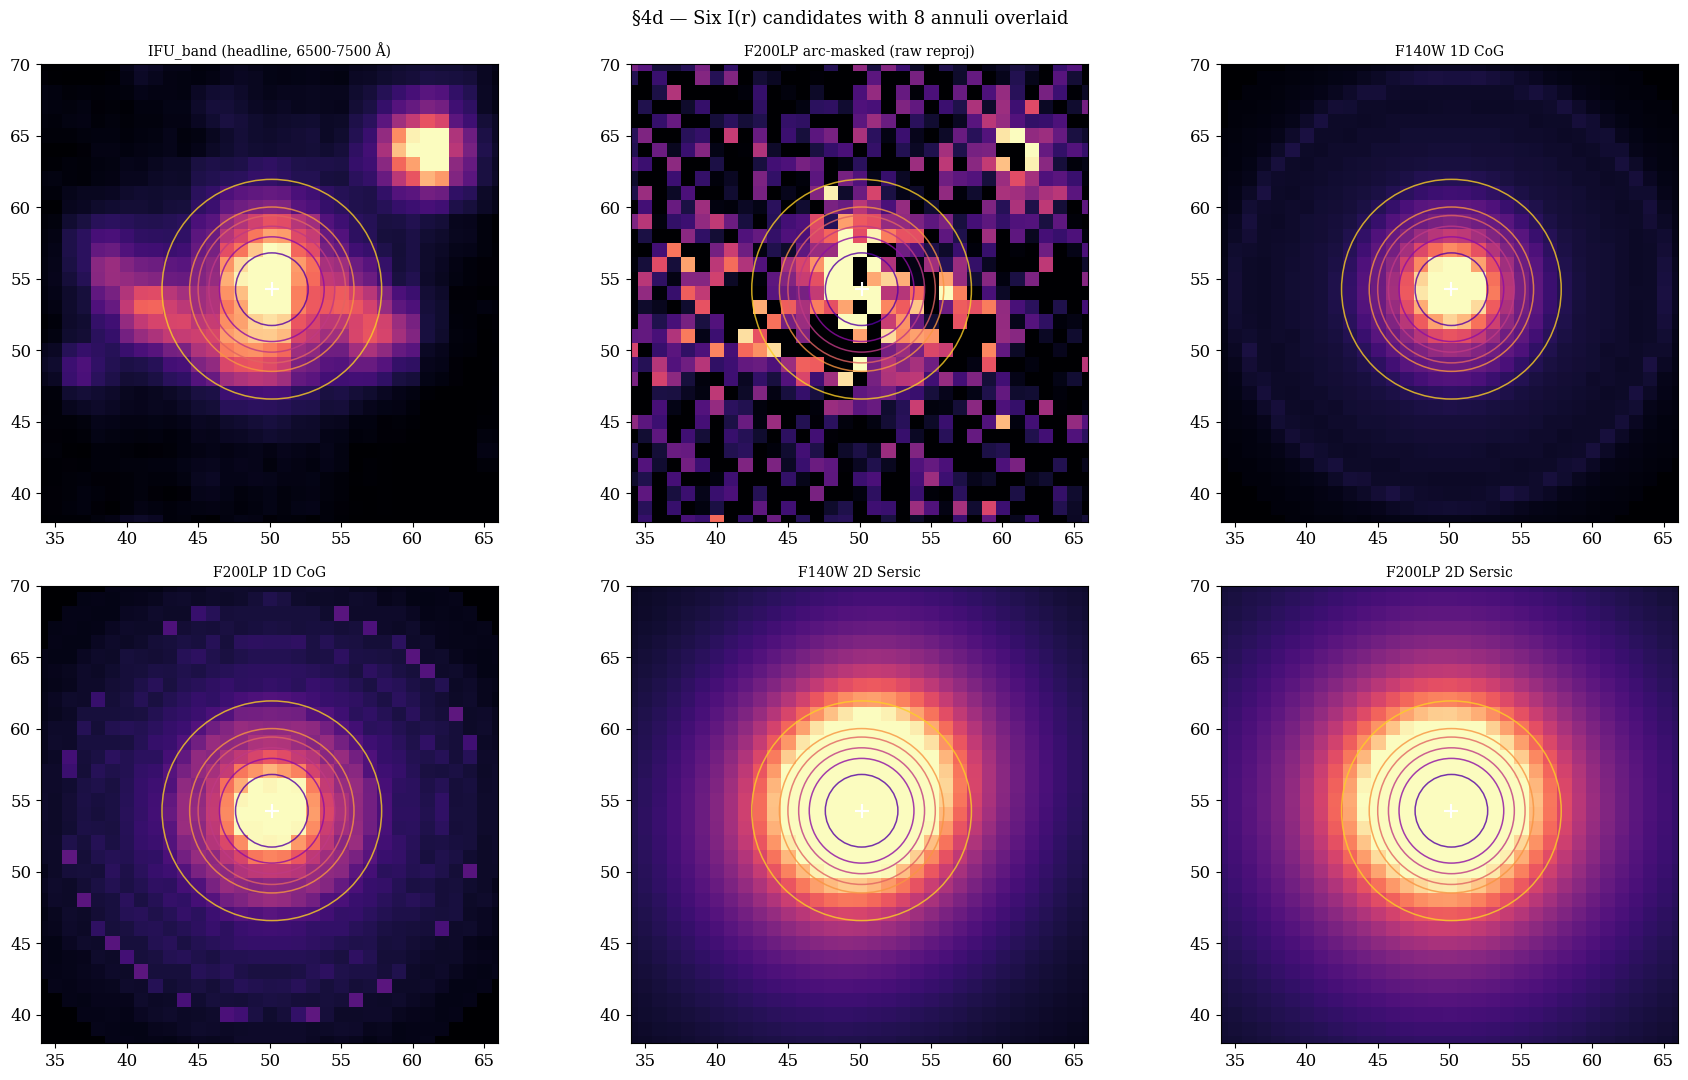

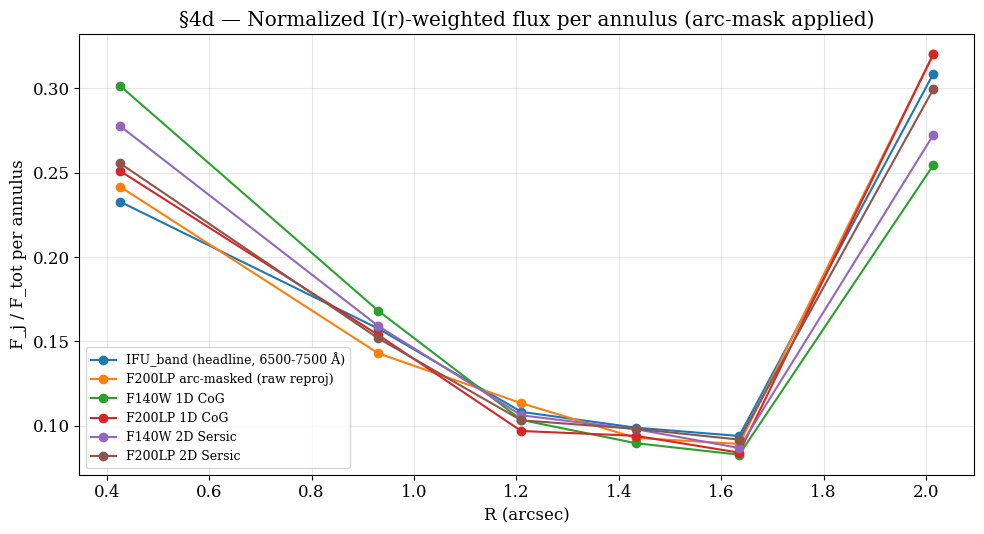

In [12]:
# F200LP (raw arc-masked) reprojected — for comparison with the Sersic-filled version
img_f200_masked = np.where(mask_f200, 0.0, img_f200)
def _reproj(img_hst, wcs_hst_):
    yy_, xx_ = np.mgrid[:ny, :nx]
    ra_g, dec_g = wcs_ifu.pixel_to_world_values(xx_.ravel(), yy_.ravel())
    xh_, yh_ = wcs_hst_.world_to_pixel_values(ra_g, dec_g)
    I_ = map_coordinates(np.nan_to_num(img_hst), [yh_, xh_],
                         order=1, mode='constant', cval=0.0).reshape(ny, nx)
    return np.clip(I_, 0, None)

I_F200LP_masked_reproj = _reproj(img_f200_masked, wcs_f200)
I_headline = np.clip(ifu_band, 0, None)

I_maps = {
    'IFU_band (headline, 6500-7500 Å)': I_headline,
    'F200LP arc-masked (raw reproj)': I_F200LP_masked_reproj,
    'F140W 1D CoG': I_F140W_1D,
    'F200LP 1D CoG': I_F200LP_1D,
    'F140W 2D Sersic': I_F140W_2D,
    'F200LP 2D Sersic': I_F200LP_2D,
}

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
delta = 16
y1 = max(0, int(cy_ifu-delta)); y2 = min(ny, int(cy_ifu+delta))
x1 = max(0, int(cx_ifu-delta)); x2 = min(nx, int(cx_ifu+delta))
for ax, (name, Imap) in zip(axes.ravel(), I_maps.items()):
    pos = Imap[Imap>0]
    vmax = np.percentile(pos, 99) if len(pos) else 1
    ax.imshow(Imap, origin='lower', cmap='magma',
              extent=[-0.5, nx-0.5, -0.5, ny-0.5], vmin=0, vmax=vmax)
    for j in range(n_ann):
        ax.add_patch(Circle((cx_ifu, cy_ifu), r_edges[j+1]/pix_scale_ifu,
                            fill=False, edgecolor=ann_cols[j], lw=1.1, alpha=0.8))
    ax.plot(cx_ifu, cy_ifu, 'w+', ms=10, mew=1.5)
    ax.set_xlim(x1, x2); ax.set_ylim(y1, y2)
    ax.set_title(name, fontsize=10)
fig.suptitle('§4d — Six I(r) candidates with 8 annuli overlaid', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'nb07c_s4d_Imaps.png'), dpi=150, bbox_inches='tight')
plt.show()

# 1D radial F_j profile per I-source
fig, ax = plt.subplots(figsize=(10, 5.5))
for name, Imap in I_maps.items():
    Fj = np.array([Imap[(r_spax>=r_edges[j]) & (r_spax<r_edges[j+1]) & ~arc_spax_mask].sum()
                   for j in range(n_ann)])
    if Fj.sum() > 0:
        ax.plot(r_mid_ann, Fj/Fj.sum(), 'o-', lw=1.5, label=name)
ax.set_xlabel('R (arcsec)'); ax.set_ylabel('F_j / F_tot per annulus')
ax.set_title('§4d — Normalized I(r)-weighted flux per annulus (arc-mask applied)')
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'nb07c_s4d_Fj.png'), dpi=150, bbox_inches='tight')
plt.show()

## §5. Annular spectra with HARD arc mask

For each annulus, drop any spaxel in the reprojected F200 arc mask, then unweighted-average the cube. No contamination weighting — the arc is either physically excluded or physically included.

In [13]:
annular_spectra = []
for j in range(n_ann):
    mask_ann = (r_spax >= r_edges[j]) & (r_spax < r_edges[j+1]) & ~arc_spax_mask
    n_kept = int(mask_ann.sum())
    if n_kept < 1:
        print(f'ann{j}: N_kept=0, SKIPPING'); continue
    # I-weighted average within the annulus (Gültekin strict)
    I_in_ann = ifu_band[mask_ann]
    if I_in_ann.sum() > 0:
        w_spax = I_in_ann / I_in_ann.sum()
        flux = np.sum(cube[:, mask_ann] * w_spax[None, :], axis=1)
    else:
        flux = np.mean(cube[:, mask_ann], axis=1)  # fallback if no I-weight
    sn = np.median(flux[band_mask]) / np.median(noise_sky[band_mask])
    n_tot = int(((r_spax >= r_edges[j]) & (r_spax < r_edges[j+1])).sum())
    annular_spectra.append({
        'r_lo': r_edges[j], 'r_hi': r_edges[j+1], 'r_mid': r_mid_ann[j],
        'flux': flux, 'noise': noise_sky.copy(),
        'n_spax': n_kept, 'n_tot': n_tot, 'sn_band': float(sn),
    })
    print(f'ann{j} R={r_edges[j]:.2f}-{r_edges[j+1]:.2f}"  '
          f'N_tot={n_tot} N_kept={n_kept} (arc-dropped {n_tot-n_kept})  S/N_band={sn:.1f}')

ann0 R=0.09-0.76"  N_tot=21 N_kept=17 (arc-dropped 4)  S/N_band=6.2
ann1 R=0.76-1.10"  N_tot=21 N_kept=15 (arc-dropped 6)  S/N_band=4.7
ann2 R=1.10-1.32"  N_tot=20 N_kept=13 (arc-dropped 7)  S/N_band=3.8
ann3 R=1.32-1.55"  N_tot=21 N_kept=15 (arc-dropped 6)  S/N_band=3.0
ann4 R=1.55-1.72"  N_tot=20 N_kept=16 (arc-dropped 4)  S/N_band=2.7
ann5 R=1.72-2.30"  N_tot=81 N_kept=70 (arc-dropped 11)  S/N_band=2.2


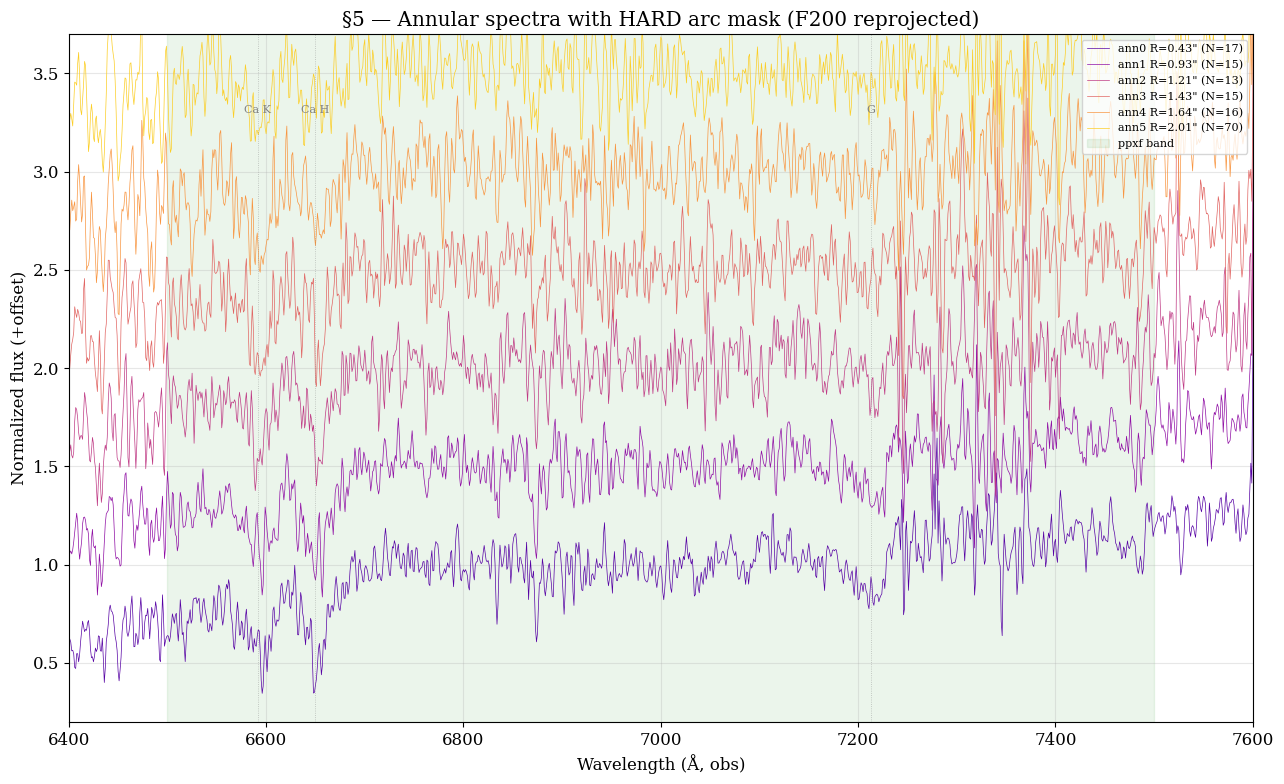

In [14]:
# Stack annular spectra
fig, ax = plt.subplots(figsize=(13, 8))
off = np.arange(len(annular_spectra)) * 0.5
for j, (s, off_j, c) in enumerate(zip(annular_spectra, off, ann_cols)):
    norm = s['flux'] / max(np.median(s['flux'][band_mask]), 1e-9)
    ax.plot(lam, norm + off_j, lw=0.5, color=c,
            label=f'ann{j} R={s["r_mid"]:.2f}" (N={s["n_spax"]})')
ax.axvspan(6500, 7500, color='green', alpha=0.08, label='ppxf band')
# line markers (z=0.67564)
for lname, l_rest in {'Ca K': 3933.66, 'Ca H': 3968.47, 'G': 4304.40}.items():
    l_obs = l_rest * (1 + Z_SYSTEMIC)
    ax.axvline(l_obs, color='gray', ls=':', lw=0.6, alpha=0.5)
    ax.text(l_obs, off[-1]+0.8, lname, fontsize=8, ha='center', color='gray')
ax.set_xlim(6400, 7600); ax.set_ylim(0.2, off[-1]+1.2)
ax.set_xlabel('Wavelength (Å, obs)'); ax.set_ylabel('Normalized flux (+offset)')
ax.set_title('§5 — Annular spectra with HARD arc mask (F200 reprojected)')
ax.legend(fontsize=8, loc='upper right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'nb07c_s5_spectra.png'), dpi=150, bbox_inches='tight')
plt.show()

## §6. Per-SPS bootstrap ppxf per annulus (N_BOOTSTRAP)

Fast-path: if cached files exist in `results/annular_bootstrap_07a/`, reload them instead of re-running the bootstrap loop. Delete the cache to force a fresh run.

σ(R) physics check: flag annuli with σ > 400 km/s as arc-contaminated. Flag ann0 as SEEING_LIMITED when outer edge < 0.64".

In [15]:
sps_colors = {'fsps': 'C0', 'emiles': 'C1', 'xsl': 'C2'}
bootstrap_results = {}
_all_exist = all(os.path.exists(os.path.join(ANNULAR_DIR, f'ann{j}_{sps}.npz'))
                 for j in range(len(annular_spectra)) for sps in SPS_LIBS)

if _all_exist:
    print(f'FAST-PATH: reloading from {ANNULAR_DIR}')
    for j, s in enumerate(annular_spectra):
        for sps in SPS_LIBS:
            d = dict(np.load(os.path.join(ANNULAR_DIR, f'ann{j}_{sps}.npz'), allow_pickle=True))
            for k in list(d.keys()):
                if d[k].shape == (): d[k] = d[k].item()
            bootstrap_results[(j, sps)] = d
            print(f'  loaded ann{j} ({s["r_mid"]:.2f}") / {sps}: '
                  f'σ range {d["sig_orig"].min():.0f}-{d["sig_orig"].max():.0f}')
    print('FAST-PATH DONE.')
else:
    t_total = clock()
    for j, s in enumerate(annular_spectra):
        for sps in SPS_LIBS:
            t0 = clock()
            inputs = setup_ppxf_inputs_from_spectrum(
                s['flux'], s['noise'], hdr, sps_name=sps, z=Z_SYSTEMIC, verbose=False)
            n_pix = len(inputs['galaxy']); n_deg = len(DEGREES)
            best_fit = np.zeros((n_deg, n_pix))
            V_o = np.zeros(n_deg); sig_o = np.zeros(n_deg); chi_o = np.zeros(n_deg)
            V_b = np.full((n_deg, N_BOOTSTRAP), np.nan)
            sig_b = np.full((n_deg, N_BOOTSTRAP), np.nan)
            for i, deg in enumerate(DEGREES):
                pp = ppxf(inputs['sps'].templates, inputs['galaxy'], inputs['noise'],
                         inputs['velscale'], inputs['start'],
                         goodpixels=inputs['goodpixels'], plot=False, moments=2,
                         trig=False, degree=int(deg), mdegree=0,
                         lam=inputs['lam_gal_rest'], lam_temp=inputs['lam_temp'], quiet=True)
                best_fit[i] = pp.bestfit; V_o[i] = pp.sol[0]; sig_o[i] = pp.sol[1]; chi_o[i] = pp.chi2
                rb = run_bootstrap_single_degree(inputs, degree=int(deg),
                    best_fit_spectrum=pp.bestfit, n_bootstrap=N_BOOTSTRAP,
                    window=WINDOW, seed=BOOT_SEED + 100*j + i, n_jobs=8)
                V_b[i] = rb['V_samples']; sig_b[i] = rb['sigma_samples']
            bootstrap_results[(j, sps)] = {
                'V_orig': V_o, 'sig_orig': sig_o, 'chi2_orig': chi_o,
                'V_boot': V_b, 'sig_boot': sig_b, 'best_fit': best_fit,
                'galaxy': inputs['galaxy'], 'noise': inputs['noise'],
                'lam_gal_rest': inputs['lam_gal_rest'], 'goodpixels': inputs['goodpixels'],
                'degrees': np.asarray(DEGREES), 'z_input': Z_SYSTEMIC,
                'r_mid': s['r_mid'], 'r_lo': s['r_lo'], 'r_hi': s['r_hi'], 'sps': sps,
            }
            np.savez(os.path.join(ANNULAR_DIR, f'ann{j}_{sps}.npz'),
                     **{k: v for k, v in bootstrap_results[(j, sps)].items() if k != 'goodpixels'},
                     goodpixels=bootstrap_results[(j, sps)]['goodpixels'])
            print(f'  ann{j} ({s["r_mid"]:.2f}") / {sps}: '
                  f'σ={sig_o.min():.0f}-{sig_o.max():.0f}  {clock()-t0:.1f}s')
    print(f'\n*** Total bootstrap time: {(clock()-t_total)/60:.1f} min ***')

FAST-PATH: reloading from ../results/annular_bootstrap_07c
  loaded ann0 (0.43") / fsps: σ range 196-208
  loaded ann0 (0.43") / emiles: σ range 200-212
  loaded ann0 (0.43") / xsl: σ range 216-230
  loaded ann1 (0.93") / fsps: σ range 230-251
  loaded ann1 (0.93") / emiles: σ range 245-258
  loaded ann1 (0.93") / xsl: σ range 259-274
  loaded ann2 (1.21") / fsps: σ range 210-234
  loaded ann2 (1.21") / emiles: σ range 244-255
  loaded ann2 (1.21") / xsl: σ range 257-266
  loaded ann3 (1.43") / fsps: σ range 24-384
  loaded ann3 (1.43") / emiles: σ range 228-448
  loaded ann3 (1.43") / xsl: σ range 194-439
  loaded ann4 (1.64") / fsps: σ range 253-504
  loaded ann4 (1.64") / emiles: σ range 271-426
  loaded ann4 (1.64") / xsl: σ range 268-348
  loaded ann5 (2.01") / fsps: σ range 545-707
  loaded ann5 (2.01") / emiles: σ range 557-663
  loaded ann5 (2.01") / xsl: σ range 578-675
FAST-PATH DONE.


Hard cap σ > 400 km/s → arc. Seeing-limit R<0.64"
  ann0 R=0.43"  σ_pooled=207  V_pooled=-15  (ok)
  ann1 R=0.93"  σ_pooled=255  V_pooled=-24  (ok)
  ann2 R=1.21"  σ_pooled=249  V_pooled=-1  (ok)
  ann3 R=1.43"  σ_pooled=291  V_pooled=-1  (ok)
  ann4 R=1.64"  σ_pooled=307  V_pooled=+3  (ok)
  ann5 R=2.01"  σ_pooled=572  V_pooled=+18  *** OUTER (r > R_safe, pre-flagged) ***

FLAGGED_ANNULI (arc): [5]


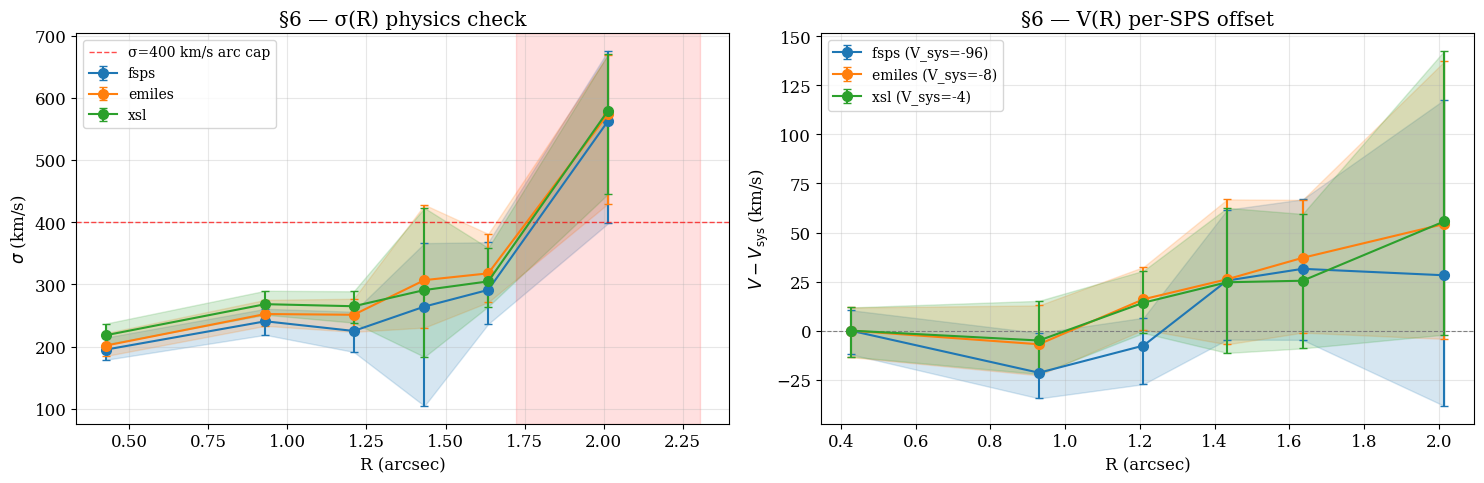

In [16]:
# σ(R) physics check — absolute cap, seeing-limited flag
combined_sig_p50 = np.zeros(len(annular_spectra))
combined_V_p50 = np.zeros(len(annular_spectra))
for j in range(len(annular_spectra)):
    pooled_s = np.concatenate([bootstrap_results[(j, s)]['sig_boot'].ravel() for s in SPS_LIBS])
    pooled_s = pooled_s[np.isfinite(pooled_s)]
    combined_sig_p50[j] = np.median(pooled_s)
    pooled_v = np.concatenate([bootstrap_results[(j, s)]['V_boot'].ravel() for s in SPS_LIBS])
    pooled_v = pooled_v[np.isfinite(pooled_v)]
    combined_V_p50[j] = np.median(pooled_v)

seeing_limit = 0.5 * KCWI_SEEING_FWHM
ann0_seeing_limited = r_edges[1] < seeing_limit

# Start with the outer bin pre-flagged (it's outside R_safe by design)
FLAGGED_ANNULI = list(OUTER_ANNULI)
print(f'Hard cap σ > {SIGMA_MAX_CAP:.0f} km/s → arc. Seeing-limit R<{seeing_limit:.2f}"')
for j, (r, s, v) in enumerate(zip(r_mid_ann, combined_sig_p50, combined_V_p50)):
    tags = []
    if s > SIGMA_MAX_CAP and j not in FLAGGED_ANNULI:
        tags.append('ARC'); FLAGGED_ANNULI.append(j)
    elif j in OUTER_ANNULI: tags.append('OUTER (r > R_safe, pre-flagged)')
    if j == 0 and ann0_seeing_limited: tags.append('SEEING')
    status = '  *** ' + '+'.join(tags) + ' ***' if tags else '  (ok)'
    print(f'  ann{j} R={r:.2f}"  σ_pooled={s:.0f}  V_pooled={v:+.0f}{status}')

print(f'\nFLAGGED_ANNULI (arc): {FLAGGED_ANNULI}')

# Plot σ(R) and V(R)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sig_at_ann = {}; V_at_ann = {}
for sps in SPS_LIBS:
    p16, p50, p84 = [], [], []
    Vp16, Vp50, Vp84 = [], [], []
    for j in range(len(annular_spectra)):
        allS = bootstrap_results[(j, sps)]['sig_boot'].ravel(); allS = allS[np.isfinite(allS)]
        p16.append(np.percentile(allS, 16)); p50.append(np.percentile(allS, 50)); p84.append(np.percentile(allS, 84))
        allV = bootstrap_results[(j, sps)]['V_boot'].ravel(); allV = allV[np.isfinite(allV)]
        Vp16.append(np.percentile(allV, 16)); Vp50.append(np.percentile(allV, 50)); Vp84.append(np.percentile(allV, 84))
    sig_at_ann[sps] = {'p16': np.array(p16), 'p50': np.array(p50), 'p84': np.array(p84)}
    V_at_ann[sps] = {'p16': np.array(Vp16), 'p50': np.array(Vp50), 'p84': np.array(Vp84)}
    axes[0].fill_between(r_mid_ann, sig_at_ann[sps]['p16'], sig_at_ann[sps]['p84'],
                         color=sps_colors[sps], alpha=0.18)
    axes[0].errorbar(r_mid_ann, sig_at_ann[sps]['p50'],
                     yerr=[sig_at_ann[sps]['p50']-sig_at_ann[sps]['p16'],
                           sig_at_ann[sps]['p84']-sig_at_ann[sps]['p50']],
                     fmt='o-', ms=7, color=sps_colors[sps], capsize=3, label=sps)
    V_sys = V_at_ann[sps]['p50'][0]
    axes[1].fill_between(r_mid_ann, V_at_ann[sps]['p16']-V_sys, V_at_ann[sps]['p84']-V_sys,
                         color=sps_colors[sps], alpha=0.18)
    axes[1].errorbar(r_mid_ann, V_at_ann[sps]['p50']-V_sys,
                     yerr=[V_at_ann[sps]['p50']-V_at_ann[sps]['p16'],
                           V_at_ann[sps]['p84']-V_at_ann[sps]['p50']],
                     fmt='o-', ms=7, color=sps_colors[sps], capsize=3,
                     label=f'{sps} (V_sys={V_sys:+.0f})')
for j in FLAGGED_ANNULI:
    axes[0].axvspan(r_edges[j], r_edges[j+1], color='red', alpha=0.12)
if ann0_seeing_limited:
    axes[0].axvspan(r_edges[0], r_edges[1], color='orange', alpha=0.08)
axes[0].axhline(SIGMA_MAX_CAP, color='red', ls='--', lw=1.0, alpha=0.7,
                label=f'σ={SIGMA_MAX_CAP:.0f} km/s arc cap')
axes[0].set_xlabel('R (arcsec)'); axes[0].set_ylabel(r'$\sigma$ (km/s)')
axes[0].set_title('§6 — σ(R) physics check')
axes[0].legend(fontsize=10); axes[0].grid(alpha=0.3)
axes[1].axhline(0, color='gray', ls='--', lw=0.8)
axes[1].set_xlabel('R (arcsec)'); axes[1].set_ylabel(r'$V-V_{\rm sys}$ (km/s)')
axes[1].set_title('§6 — V(R) per-SPS offset')
axes[1].legend(fontsize=10); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'nb07c_s6_sig_V_vs_R.png'), dpi=150, bbox_inches='tight')
plt.show()

## §6d. Continuum-dilution diagnostic (evidence, not a correction)

**Hypothesis**: the σ rise with R in raw ppxf output is partially driven by continuum dilution. The lensed z=1.302 arc adds rest-UV flux (~2800-3200 Å) in our observed 6500-7500 Å window; that light is featureless relative to the deflector's Ca H+K + G-band absorption, so it shrinks each line's equivalent width. ppxf generally responds to shallower lines by broadening its best-fit LOSVD.

**This is a qualitative diagnostic, NOT a rigorous correction.** We measure EW(Ca K + Ca H + G-band) per annulus and compare its decrease with the σ_obs rise. If the two trends correlate, dilution is a contributing factor. We do *not* claim the naive ratio `σ × (EW_ann / EW_ann0)` recovers the true σ — ppxf's additive polynomial + amplitude degrees of freedom can absorb some of the dilution, so the heuristic likely over-corrects.

**What the EW data can rigorously show:**
- EW decrease with R → direct empirical evidence that featureless flux is added to the outer annuli.
- EW-σ_obs anti-correlation → dilution is plausibly *a* driver of the σ rise (other drivers may also contribute).

**What we should NOT claim**: a specific "corrected" σ value.

**For the headline σ_e we report**: use the cumulative I-weighted ppxf from §6cum, which naturally suppresses contribution from the diluted outer regions (the central bright deflector dominates the I-weighted aperture average).


In [17]:
# Per-annulus EW for Ca K, Ca H, G-band — test the dilution hypothesis
# Line centers (observed, z=0.67564)
CA_K_OBS = 3933.66 * (1 + Z_SYSTEMIC)    # ~6590 Å
CA_H_OBS = 3968.47 * (1 + Z_SYSTEMIC)    # ~6649 Å
GBAND_OBS = 4304.40 * (1 + Z_SYSTEMIC)   # ~7211 Å

def measure_ew(lam_, flux_, center, halfw=12, cont_half=25):
    """Simple linear-continuum EW in Å. flux is per-annulus integrated spectrum,
    center is observed-frame line wavelength (Å)."""
    line_mask = (lam_ > center - halfw) & (lam_ < center + halfw)
    cont_mask = (((lam_ > center - halfw - cont_half) & (lam_ < center - halfw))
              | ((lam_ > center + halfw) & (lam_ < center + halfw + cont_half)))
    if line_mask.sum() == 0 or cont_mask.sum() < 5:
        return np.nan
    c1, c0 = np.polyfit(lam_[cont_mask], flux_[cont_mask], 1)
    cont_at_line = c1 * lam_[line_mask] + c0
    return float(np.trapezoid(1.0 - flux_[line_mask] / cont_at_line, lam_[line_mask]))

ew_table = []
for j, s in enumerate(annular_spectra):
    ek = measure_ew(lam, s['flux'], CA_K_OBS, halfw=12, cont_half=25)
    eh = measure_ew(lam, s['flux'], CA_H_OBS, halfw=12, cont_half=25)
    eg = measure_ew(lam, s['flux'], GBAND_OBS, halfw=20, cont_half=25)
    ew_sum = ek + eh + eg
    # σ_pooled from §6: use the combined_sig_p50 array computed there
    sig_obs = combined_sig_p50[j]
    ew_table.append({'ann': j, 'r': s['r_mid'], 'N_kept': s['n_spax'],
                     'sig_obs': sig_obs, 'EW_K': ek, 'EW_H': eh, 'EW_G': eg,
                     'EW_sum': ew_sum})

ew0 = ew_table[0]['EW_sum']
for r in ew_table:
    r['EW_ratio'] = r['EW_sum'] / ew0 if ew0 > 0 else np.nan
    # NOT a rigorous correction — just σ_obs × (EW_ann/EW_ann0) heuristic
    r['sig_scaled'] = r['sig_obs'] * r['EW_ratio']

print(f'{"ann":>4} {"r_mid":>7} {"N_kept":>7} {"σ_obs":>7} '
      f'{"EW(CaK)":>9} {"EW(CaH)":>9} {"EW(Gband)":>10} '
      f'{"EW_sum":>8} {"EW/EW_ann0":>11} {"σ×EWrat":>8}')
print('-' * 95)
for r in ew_table:
    print(f'{r["ann"]:>4d} {r["r"]:>7.2f} {r["N_kept"]:>7d} {r["sig_obs"]:>7.0f} '
          f'{r["EW_K"]:>9.3f} {r["EW_H"]:>9.3f} {r["EW_G"]:>10.3f} '
          f'{r["EW_sum"]:>8.3f} {r["EW_ratio"]:>11.3f} {r["sig_scaled"]:>8.0f}')
print(f'\nHeuristic scaling (upper bound on dilution effect):  σ_obs × (EW_ann / EW_ann0)')
print(f'If σ_scaled is roughly flat → the σ rise trend is CONSISTENT with dilution (not proof).')

 ann   r_mid  N_kept   σ_obs   EW(CaK)   EW(CaH)  EW(Gband)   EW_sum  EW/EW_ann0  σ×EWrat
-----------------------------------------------------------------------------------------------
   0    0.43      17     207     5.641     7.555      6.270   19.466       1.000      207
   1    0.93      15     255     5.297     7.312      5.774   18.383       0.944      240
   2    1.21      13     249     5.903     6.412      2.656   14.971       0.769      191
   3    1.43      15     291     7.221     4.587      1.016   12.824       0.659      192
   4    1.64      16     307     6.752     3.179      0.931   10.862       0.558      171
   5    2.01      70     572     4.572     3.204      3.003   10.780       0.554      317

Heuristic scaling (upper bound on dilution effect):  σ_obs × (EW_ann / EW_ann0)
If σ_scaled is roughly flat → the σ rise trend is CONSISTENT with dilution (not proof).


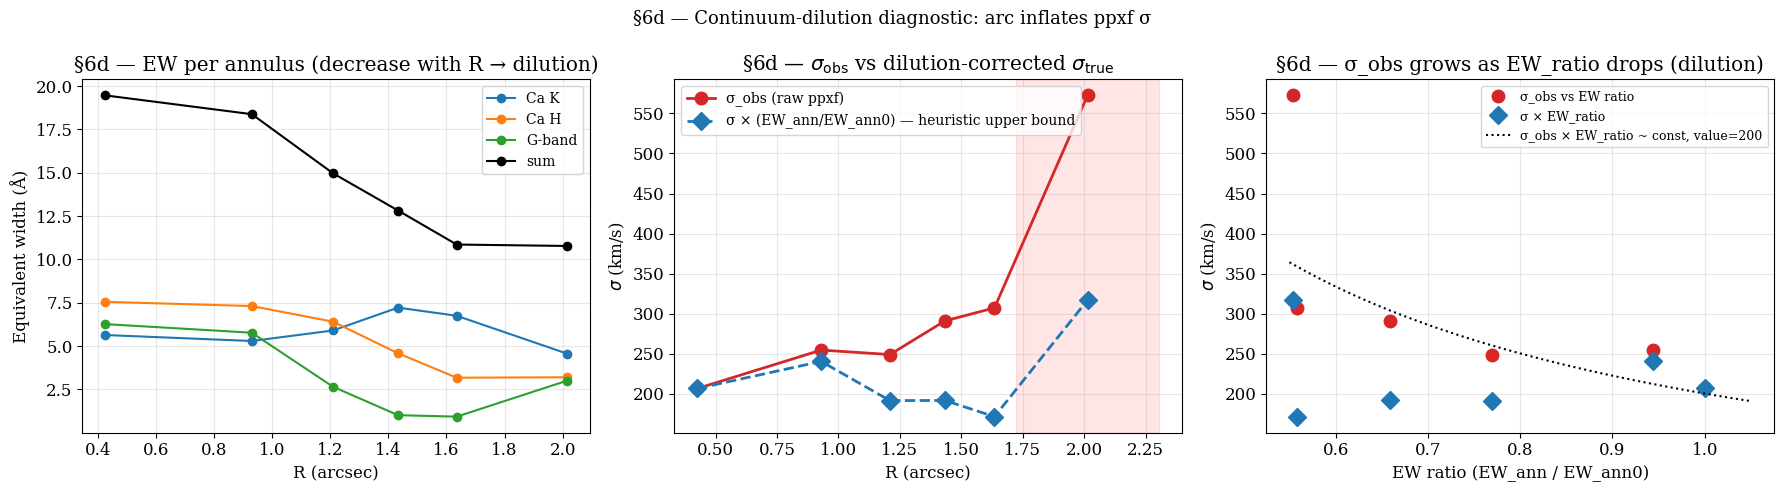


--- DILUTION-SCALED SIGMA (HEURISTIC, NOT A RIGOROUS CORRECTION) ---
Inner-bin σ×EW_ratio mean (ann0..ann4): 200 km/s
σ × (EW_ann/EW_ann0) at each annulus (heuristic):
  ann0 R=0.43"  σ_scaled = 207 km/s
  ann1 R=0.93"  σ_scaled = 240 km/s
  ann2 R=1.21"  σ_scaled = 191 km/s
  ann3 R=1.43"  σ_scaled = 192 km/s
  ann4 R=1.64"  σ_scaled = 171 km/s
  ann5 R=2.01"  σ_scaled = 317 km/s  *** arc ***

AGEL0206 is an elliptical bulge; σ(R) should be flat or gently decreasing.
If σ_scaled is flat, the σ_obs rise is CONSISTENT with dilution-driven inflation.
→ This is evidence, NOT a proof that σ_true ≈ σ_scaled. ppxf's
→ additive polynomial can absorb some of the dilution. The cumulative σ_e (§6cum) is the physically-clean
  headline number; it naturally avoids dilution by concentrating on the bright,
  undiluted center.


In [18]:
# Plot: EW(R), σ_obs(R), σ_true(R) on one figure
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
r_ann = [r['r'] for r in ew_table]

# (a) EW vs R
ax = axes[0]
for name, key, c in [('Ca K', 'EW_K', 'C0'), ('Ca H', 'EW_H', 'C1'),
                     ('G-band', 'EW_G', 'C2'), ('sum', 'EW_sum', 'black')]:
    vals = [r[key] for r in ew_table]
    ax.plot(r_ann, vals, 'o-', color=c, lw=1.5, ms=6, label=name)
ax.set_xlabel('R (arcsec)'); ax.set_ylabel('Equivalent width (Å)')
ax.set_title('§6d — EW per annulus (decrease with R → dilution)')
ax.grid(alpha=0.3); ax.legend(fontsize=10)

# (b) σ_obs vs σ_true
ax = axes[1]
sigs_obs = [r['sig_obs'] for r in ew_table]
sigs_scaled = [r['sig_scaled'] for r in ew_table]
ax.plot(r_ann, sigs_obs, 'o-', color='C3', lw=2, ms=9, label='σ_obs (raw ppxf)')
ax.plot(r_ann, sigs_scaled, 'D--', color='C0', lw=2, ms=9,
        label='σ × (EW_ann/EW_ann0) — heuristic upper bound')
# Shade the arc/outer zone
for j in FLAGGED_ANNULI:
    ax.axvspan(r_edges[j], r_edges[j+1], color='red', alpha=0.1)
if ann0_seeing_limited:
    ax.axvspan(r_edges[0], r_edges[1], color='orange', alpha=0.08)
ax.set_xlabel('R (arcsec)'); ax.set_ylabel(r'$\sigma$ (km/s)')
ax.set_title(r'§6d — $\sigma_{\rm obs}$ vs dilution-corrected $\sigma_{\rm true}$')
ax.legend(fontsize=10); ax.grid(alpha=0.3)

# (c) EW_ratio vs σ inflation, to show they correlate
ax = axes[2]
inflation = np.array(sigs_obs) / np.array(sigs_scaled)
ew_ratios = np.array([r['EW_ratio'] for r in ew_table])
ax.plot(ew_ratios, sigs_obs, 'o', color='C3', ms=9, label='σ_obs vs EW ratio')
ax.plot(ew_ratios, sigs_scaled, 'D', color='C0', ms=9, label='σ × EW_ratio')
# Theoretical line: σ_obs = σ_true / EW_ratio, so σ_obs × EW_ratio = σ_true = const
# For flat σ_true = σ_obs_ann0, expected σ_obs = σ_true / EW_ratio
x_th = np.linspace(0.55, 1.05, 50)
sig_scaled_pred = np.mean(sigs_scaled[:-1])  # use the inner bins' average σ_true
ax.plot(x_th, sig_scaled_pred / x_th, 'k:', lw=1.5,
        label=f'σ_obs × EW_ratio ~ const, value={sig_scaled_pred:.0f}')
ax.set_xlabel('EW ratio (EW_ann / EW_ann0)'); ax.set_ylabel(r'$\sigma$ (km/s)')
ax.set_title('§6d — σ_obs grows as EW_ratio drops (dilution)')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

fig.suptitle('§6d — Continuum-dilution diagnostic: arc inflates ppxf σ', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'nb07c_s6d_dilution.png'), dpi=150, bbox_inches='tight')
plt.show()

# Summary
print('\n--- DILUTION-SCALED SIGMA (HEURISTIC, NOT A RIGOROUS CORRECTION) ---')
print(f'Inner-bin σ×EW_ratio mean (ann0..ann{len(ew_table)-2}): '
      f'{np.mean([r["sig_scaled"] for r in ew_table[:-1]]):.0f} km/s')
print(f'σ × (EW_ann/EW_ann0) at each annulus (heuristic):')
for r in ew_table:
    marker = '  *** arc ***' if r['ann'] in FLAGGED_ANNULI else ''
    print(f'  ann{r["ann"]} R={r["r"]:.2f}"  σ_scaled = {r["sig_scaled"]:.0f} km/s{marker}')
print()
print('AGEL0206 is an elliptical bulge; σ(R) should be flat or gently decreasing.\nIf σ_scaled is flat, the σ_obs rise is CONSISTENT with dilution-driven inflation.')
print('→ This is evidence, NOT a proof that σ_true ≈ σ_scaled. ppxf\'s')
print('→ additive polynomial can absorb some of the dilution. The cumulative σ_e (§6cum) is the physically-clean')
print('  headline number; it naturally avoids dilution by concentrating on the bright,')
print('  undiluted center.')

## §6cum. Cumulative ppxf (I-weighted expanding apertures)

For each R_max in r_edges[1:], I(r)-weight the spaxel average with the headline I = IFU 6500-7500 Å band, ppxf+bootstrap → σ_e(<R_max) directly. Hard arc mask still applied.

In [19]:
cum_apertures = []
I_weight_spax = np.clip(ifu_band, 0, None)
for r_max in r_edges[1:]:
    sel = (r_spax < r_max) & ~arc_spax_mask
    n_kept = int(sel.sum())
    if n_kept < 1:
        continue
    w = I_weight_spax[sel]
    w_norm = w / max(w.sum(), 1e-30)
    flux = np.sum(cube[:, sel] * w_norm[None, :], axis=1)
    sn = np.median(flux[band_mask]) / np.median(noise_sky[band_mask])
    cum_apertures.append({'r_max': r_max, 'flux': flux, 'noise': noise_sky.copy(),
                          'n_spax': n_kept, 'sn_band': float(sn)})
    print(f'Cum R<{r_max:.3f}"  N_kept={n_kept}  S/N_band={sn:.1f}')

Cum R<0.762"  N_kept=17  S/N_band=6.2
Cum R<1.099"  N_kept=32  S/N_band=5.6
Cum R<1.321"  N_kept=45  S/N_band=5.2
Cum R<1.546"  N_kept=60  S/N_band=4.9
Cum R<1.724"  N_kept=76  S/N_band=4.6
Cum R<2.305"  N_kept=146  S/N_band=3.8


In [20]:
cum_bootstrap = {}
_all_exist = all(
    os.path.exists(os.path.join(ANNULAR_DIR, f'cumR_{a["r_max"]:.3f}_{sps}.npz'.replace('.', 'p', 1)))
    for a in cum_apertures for sps in SPS_LIBS
)
if _all_exist:
    print(f'FAST-PATH: reloading cum from {ANNULAR_DIR}')
    for j, a in enumerate(cum_apertures):
        for sps in SPS_LIBS:
            fn = os.path.join(ANNULAR_DIR, f'cumR_{a["r_max"]:.3f}_{sps}.npz'.replace('.', 'p', 1))
            d = dict(np.load(fn, allow_pickle=True))
            for k in list(d.keys()):
                if d[k].shape == (): d[k] = d[k].item()
            cum_bootstrap[(j, sps)] = d
    print('FAST-PATH cum DONE')
else:
    t0_c = clock()
    for j, a in enumerate(cum_apertures):
        for sps in SPS_LIBS:
            t0 = clock()
            inputs = setup_ppxf_inputs_from_spectrum(a['flux'], a['noise'], hdr,
                sps_name=sps, z=Z_SYSTEMIC, verbose=False)
            n_pix = len(inputs['galaxy']); n_deg = len(DEGREES)
            bf = np.zeros((n_deg, n_pix))
            V_o = np.zeros(n_deg); sig_o = np.zeros(n_deg)
            V_b = np.full((n_deg, N_BOOTSTRAP), np.nan)
            sig_b = np.full((n_deg, N_BOOTSTRAP), np.nan)
            for i, deg in enumerate(DEGREES):
                pp = ppxf(inputs['sps'].templates, inputs['galaxy'], inputs['noise'],
                         inputs['velscale'], inputs['start'],
                         goodpixels=inputs['goodpixels'], plot=False, moments=2,
                         trig=False, degree=int(deg), mdegree=0,
                         lam=inputs['lam_gal_rest'], lam_temp=inputs['lam_temp'], quiet=True)
                bf[i] = pp.bestfit; V_o[i] = pp.sol[0]; sig_o[i] = pp.sol[1]
                rb = run_bootstrap_single_degree(inputs, degree=int(deg),
                    best_fit_spectrum=pp.bestfit, n_bootstrap=N_BOOTSTRAP,
                    window=WINDOW, seed=BOOT_SEED + 1000 + 100*j + i, n_jobs=8)
                V_b[i] = rb['V_samples']; sig_b[i] = rb['sigma_samples']
            cum_bootstrap[(j, sps)] = {
                'V_orig': V_o, 'sig_orig': sig_o, 'V_boot': V_b, 'sig_boot': sig_b,
                'best_fit': bf, 'galaxy': inputs['galaxy'], 'noise': inputs['noise'],
                'lam_gal_rest': inputs['lam_gal_rest'], 'goodpixels': inputs['goodpixels'],
                'degrees': np.asarray(DEGREES), 'r_max': a['r_max'], 'sps': sps,
            }
            fn = os.path.join(ANNULAR_DIR, f'cumR_{a["r_max"]:.3f}_{sps}.npz'.replace('.', 'p', 1))
            np.savez(fn, **{k: v for k, v in cum_bootstrap[(j, sps)].items() if k != 'goodpixels'},
                     goodpixels=cum_bootstrap[(j, sps)]['goodpixels'])
            print(f'  cum R<{a["r_max"]:.2f}" / {sps}: σ={sig_o.min():.0f}-{sig_o.max():.0f}  {clock()-t0:.1f}s')
    print(f'§6cum total: {(clock()-t0_c)/60:.1f} min')

FAST-PATH: reloading cum from ../results/annular_bootstrap_07c
FAST-PATH cum DONE


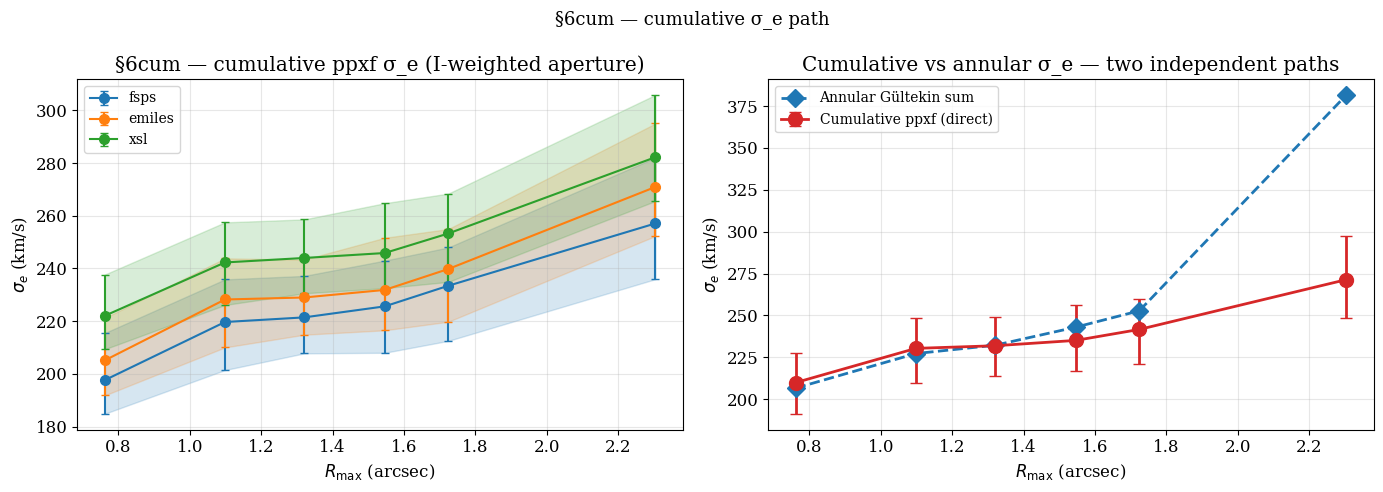


   R_max      cum ppxf (combined)     annular Gültekin
--------------------------------------------------------
   0.762   210 -19/+18 km/s            207 km/s
   1.099   230 -21/+18 km/s            227 km/s
   1.321   232 -18/+17 km/s            232 km/s
   1.546   235 -18/+21 km/s            243 km/s
   1.724   242 -21/+18 km/s            253 km/s
   2.305   271 -23/+26 km/s            382 km/s


In [21]:
# Compare cumulative ppxf σ vs annular Gültekin summation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
r_cum = [a['r_max'] for a in cum_apertures]

for sps in SPS_LIBS:
    p16, p50, p84 = [], [], []
    for j in range(len(cum_apertures)):
        all_sig = cum_bootstrap[(j, sps)]['sig_boot'].ravel()
        all_sig = all_sig[np.isfinite(all_sig)]
        p16.append(np.percentile(all_sig, 16)); p50.append(np.percentile(all_sig, 50)); p84.append(np.percentile(all_sig, 84))
    p16, p50, p84 = map(np.array, (p16, p50, p84))
    axes[0].fill_between(r_cum, p16, p84, color=sps_colors[sps], alpha=0.18)
    axes[0].errorbar(r_cum, p50, yerr=[p50-p16, p84-p50], fmt='o-', ms=7,
                     color=sps_colors[sps], capsize=3, label=sps)
axes[0].set_xlabel(r'$R_{\rm max}$ (arcsec)'); axes[0].set_ylabel(r'$\sigma_e$ (km/s)')
axes[0].set_title('§6cum — cumulative ppxf σ_e (I-weighted aperture)')
axes[0].legend(fontsize=10); axes[0].grid(alpha=0.3)

# Quick annular Gültekin with IFU_band I-weight for comparison
Fj_band = np.array([I_headline[(r_spax>=r_edges[j]) & (r_spax<r_edges[j+1]) & ~arc_spax_mask].sum()
                    for j in range(n_ann)])
sig_ann_p50 = []
sig_cum_p50 = []; sig_cum_p16 = []; sig_cum_p84 = []
for j, r_max in enumerate(r_cum):
    j_use = [jj for jj in range(n_ann) if r_edges[jj+1] <= r_max + 1e-6]
    num = 0
    for jj in j_use:
        pool_V = np.concatenate([bootstrap_results[(jj, s)]['V_boot'].ravel() for s in SPS_LIBS])
        pool_S = np.concatenate([bootstrap_results[(jj, s)]['sig_boot'].ravel() for s in SPS_LIBS])
        pool_V = pool_V[np.isfinite(pool_V)]; pool_S = pool_S[np.isfinite(pool_S)]
        V_med = np.median(pool_V); S_med = np.median(pool_S)
        V0_pool = np.concatenate([bootstrap_results[(0, s)]['V_boot'].ravel() for s in SPS_LIBS])
        V0_med = np.median(V0_pool[np.isfinite(V0_pool)])
        num += Fj_band[jj] * ((V_med - V0_med)**2 + S_med**2)
    F_tot = Fj_band[j_use].sum()
    sig_ann_p50.append(np.sqrt(num / F_tot))
    pool = np.concatenate([cum_bootstrap[(j, s)]['sig_boot'].ravel() for s in SPS_LIBS])
    pool = pool[np.isfinite(pool)]
    sig_cum_p50.append(np.percentile(pool, 50))
    sig_cum_p16.append(np.percentile(pool, 16))
    sig_cum_p84.append(np.percentile(pool, 84))
sig_ann_p50 = np.array(sig_ann_p50)
sig_cum_p50 = np.array(sig_cum_p50); sig_cum_p16 = np.array(sig_cum_p16); sig_cum_p84 = np.array(sig_cum_p84)

axes[1].errorbar(r_cum, sig_cum_p50, yerr=[sig_cum_p50-sig_cum_p16, sig_cum_p84-sig_cum_p50],
                 fmt='o-', ms=10, color='C3', capsize=4, lw=2, label='Cumulative ppxf (direct)')
axes[1].plot(r_cum, sig_ann_p50, 'D--', ms=9, color='C0', lw=2, label='Annular Gültekin sum')
axes[1].set_xlabel(r'$R_{\rm max}$ (arcsec)'); axes[1].set_ylabel(r'$\sigma_e$ (km/s)')
axes[1].set_title('Cumulative vs annular σ_e — two independent paths')
axes[1].legend(fontsize=10); axes[1].grid(alpha=0.3)

fig.suptitle('§6cum — cumulative σ_e path', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'nb07c_s6cum_sigma_vs_R.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'\n{"R_max":>8} {"cum ppxf (combined)":>24} {"annular Gültekin":>20}')
print('-' * 56)
for j, r_max in enumerate(r_cum):
    print(f'{r_max:>8.3f} {sig_cum_p50[j]:>5.0f} -{sig_cum_p50[j]-sig_cum_p16[j]:.0f}/+{sig_cum_p84[j]-sig_cum_p50[j]:.0f} km/s'
          f'       {sig_ann_p50[j]:>8.0f} km/s')

## §7. Explicit Gültekin integral per I(r) source

For each of the six I-maps from §4d, run the Monte-Carlo Gültekin integral over the 8 annuli. Report per-SPS, combined, and arc-filtered variants.

In [22]:
# Apertures labeled by actual ANNULUS OUTER EDGES (patch 4)
# Each label Rann{j} = outer edge of annulus j. This makes the "σ_e(<R)"
# numbers unambiguous when R_max doesn't land on the analytic Re/2 etc.
APERTURES_OF_INTEREST = {f'Rann{j}_{r_edges[j+1]:.2f}'.replace('.', 'p'): r_edges[j+1]
                         for j in range(n_ann)}

def run_gultekin_mc(bootstrap_results, Fj, r_edges, apertures, sps_list=SPS_LIBS,
                    n_mc=N_MC, seed=123, filter_annuli=None):
    rng = np.random.default_rng(seed)
    n_ann_local = len(r_edges) - 1
    n_deg, n_boot = bootstrap_results[(0, sps_list[0])]['sig_boot'].shape
    keep_ann = [j for j in range(n_ann_local) if filter_annuli is None or j not in filter_annuli]
    samples = {}; V_offsets = {}
    for sps in sps_list:
        V_draws = np.zeros((n_mc, n_ann_local))
        S_draws = np.zeros((n_mc, n_ann_local))
        for j in range(n_ann_local):
            if j not in keep_ann: continue
            d = bootstrap_results[(j, sps)]
            di = rng.integers(0, n_deg, size=n_mc); bi = rng.integers(0, n_boot, size=n_mc)
            V_draws[:, j] = d['V_boot'][di, bi]; S_draws[:, j] = d['sig_boot'][di, bi]
        V_sys = float(np.nanmedian(V_draws[:, keep_ann[0]]))
        V_offsets[sps] = V_sys
        for tag, r_max in apertures.items():
            j_use = [j for j in keep_ann if r_edges[j+1] <= r_max + 1e-6]
            if not j_use:
                samples[(sps, tag)] = np.full(n_mc, np.nan); continue
            F_sum = Fj[j_use].sum()
            num = np.zeros(n_mc)
            for j in j_use:
                num += Fj[j] * ((V_draws[:, j] - V_sys)**2 + S_draws[:, j]**2)
            samples[(sps, tag)] = np.sqrt(num / max(F_sum, 1e-30))
    return samples, V_offsets


# Compute F_j per I-source (arc-mask-aware)
def Fj_from_Imap(I_map):
    return np.array([I_map[(r_spax>=r_edges[j]) & (r_spax<r_edges[j+1]) & ~arc_spax_mask].sum()
                     for j in range(n_ann)])

I_maps_gultekin = {
    'IFU_band': I_headline,
    'F200LP_masked_raw': I_F200LP_masked_reproj,
    'F140W_1D_CoG': I_F140W_1D,
    'F200LP_1D_CoG': I_F200LP_1D,
    'F140W_2D_Sersic': I_F140W_2D,
    'F200LP_2D_Sersic': I_F200LP_2D,
}

gultekin = {}  # (I_src, mode) -> dict(samples, V_offsets)
for src_name, Imap in I_maps_gultekin.items():
    Fj = Fj_from_Imap(Imap)
    sam_unf, Voff_unf = run_gultekin_mc(bootstrap_results, Fj, r_edges,
                                         APERTURES_OF_INTEREST, n_mc=N_MC, seed=100, filter_annuli=None)
    sam_flt, Voff_flt = run_gultekin_mc(bootstrap_results, Fj, r_edges,
                                         APERTURES_OF_INTEREST, n_mc=N_MC, seed=101, filter_annuli=FLAGGED_ANNULI)
    gultekin[(src_name, 'unfiltered')] = {'samples': sam_unf, 'V_offsets': Voff_unf, 'Fj': Fj}
    gultekin[(src_name, 'filtered')] = {'samples': sam_flt, 'V_offsets': Voff_flt, 'Fj': Fj}

# Headline print — filtered combined-SPS per I-source
print('=' * 95)
print('HEADLINE — σ_e (filtered, combined-SPS) per I(r) source')
print('=' * 95)
print(f'{"I source":<28}  ' + '  '.join(f'{"σ_e(<R="+str(round(APERTURES_OF_INTEREST[t],2))+"\"))":>22}' for t in APERTURES_OF_INTEREST))
print('-' * 95)
for src_name in I_maps_gultekin:
    row = f'{src_name:<28}'
    for tag in APERTURES_OF_INTEREST:
        sam = gultekin[(src_name, 'filtered')]['samples']
        pool = np.concatenate([sam[(s, tag)][np.isfinite(sam[(s, tag)])] for s in SPS_LIBS])
        if len(pool):
            p16, p50, p84 = np.percentile(pool, [16, 50, 84])
            row += f' {p50:>4.0f} -{p50-p16:.0f}/+{p84-p50:.0f}'.rjust(18)
        else:
            row += f' {"n/a":>16}'
    print(row)

HEADLINE — σ_e (filtered, combined-SPS) per I(r) source
I source                              σ_e(<R=0.76"))           σ_e(<R=1.1"))          σ_e(<R=1.32"))          σ_e(<R=1.55"))          σ_e(<R=1.72"))           σ_e(<R=2.3"))
-----------------------------------------------------------------------------------------------
IFU_band                           207 -21/+20       227 -17/+18       232 -17/+18       246 -23/+29       257 -24/+27       257 -24/+27
F200LP_masked_raw                  207 -21/+20       226 -17/+18       231 -18/+17       244 -23/+28       256 -24/+27       256 -24/+27
F140W_1D_CoG                       207 -21/+20       225 -17/+18       230 -17/+17       241 -22/+26       252 -22/+24       252 -22/+24
F200LP_1D_CoG                      207 -21/+20       226 -17/+18       231 -17/+18       244 -23/+29       255 -24/+26       255 -24/+26
F140W_2D_Sersic                    207 -21/+20       225 -17/+18       230 -17/+17       243 -22/+28       254 -23/+26       25

## §7b. Flat-σ extrapolation into the outer (unsafe) annulus

For an elliptical bulge the σ(r) profile is approximately flat (or gently decreasing) beyond the inner seeing-limited region. We can exploit this to compute a proper σ_e integrated to R_e — using the actual deflector light weighting F_j at R > R_safe, but replacing the ARC-contaminated kinematic measurement with the LAST SAFE bin's (V, σ).

**Substitution**: for annulus 5 (the outer flagged bin at R=1.72-2.30"):
- Use `F_5` as measured from the IFU 6500-7500 Å I-map (this still tracks deflector light).
- Override `σ_5 := σ_4` (assume flat σ at R > R_safe).
- Override `V_5 := V_4` (assume flat rotation/zero at R > R_safe).

Then run the Gültekin sum over ALL 6 annuli with this substitution. This gives:
- A proper σ_e(<R_e) that integrates to the full R_e aperture.
- Per-SPS uncertainty propagation (σ_4, V_4 posteriors are drawn independently each MC iteration).
- A comparison point to the cumulative I-weighted ppxf σ_e(<R_e) from §6cum.

In [23]:
# Flat-σ extrapolation: σ_5 := σ_4, V_5 := V_4
def run_gultekin_mc_flat_ext(bootstrap_results, Fj, r_edges, sps_list=SPS_LIBS,
                              n_mc=N_MC, seed=456):
    """Gültekin σ_e with outer annuli inheriting (V, σ) from the last safe bin."""
    rng = np.random.default_rng(seed)
    n_ann_local = len(r_edges) - 1
    n_deg, n_boot = bootstrap_results[(0, sps_list[0])]['sig_boot'].shape
    # Last safe annulus = innermost flagged, minus 1
    last_safe = min(OUTER_ANNULI) - 1  # OUTER_ANNULI = [5] in nb07c
    samples = {}
    V_offsets = {}
    for sps in sps_list:
        V_draws = np.zeros((n_mc, n_ann_local))
        S_draws = np.zeros((n_mc, n_ann_local))
        # Safe-zone annuli: draw independently
        for j in range(n_ann_local):
            if j <= last_safe:
                d = bootstrap_results[(j, sps)]
                di = rng.integers(0, n_deg, size=n_mc); bi = rng.integers(0, n_boot, size=n_mc)
                V_draws[:, j] = d['V_boot'][di, bi]
                S_draws[:, j] = d['sig_boot'][di, bi]
        # Outer annuli: inherit (V, σ) from last safe bin per MC draw
        for j in range(last_safe + 1, n_ann_local):
            V_draws[:, j] = V_draws[:, last_safe]
            S_draws[:, j] = S_draws[:, last_safe]
        # V_sys = median of ann0 for each SPS
        V_sys = float(np.nanmedian(V_draws[:, 0]))
        V_offsets[sps] = V_sys
        # σ_e per aperture (now includes ALL annuli)
        full_r_max = r_edges[-1]  # = R_e
        F_sum = Fj.sum()
        num = np.zeros(n_mc)
        for j in range(n_ann_local):
            num += Fj[j] * ((V_draws[:, j] - V_sys)**2 + S_draws[:, j]**2)
        samples[(sps, f'Re_flat_ext')] = np.sqrt(num / max(F_sum, 1e-30))
    return samples, V_offsets

# Run with the headline IFU_band I-weight
Fj_headline = Fj_from_Imap(I_headline)
sam_flat, Voff_flat = run_gultekin_mc_flat_ext(bootstrap_results, Fj_headline, r_edges,
                                                n_mc=N_MC, seed=777)

print('=' * 85)
print('§7b HEADLINE — σ_e(<R_e) with flat-σ extrapolation into outer annulus')
print('  (σ_ann5 := σ_ann4, V_ann5 := V_ann4; Σ over ALL 6 annuli)')
print('=' * 85)
print(f'I(r) = IFU_band, R_e = {R_E:.3f}"')
last_safe = min(OUTER_ANNULI) - 1
print(f'Last safe annulus: ann{last_safe} (R={r_edges[last_safe]:.2f}-{r_edges[last_safe+1]:.2f}")')
print(f'F_sum total = {Fj_headline.sum():.3e}  '
      f'(F_outer = {Fj_headline[-1]:.3e} = {100*Fj_headline[-1]/Fj_headline.sum():.0f}% of total)\n')

for sps in SPS_LIBS:
    s = sam_flat[(sps, 'Re_flat_ext')]
    s = s[np.isfinite(s)]
    p16, p50, p84 = np.percentile(s, [16, 50, 84])
    print(f'  {sps:<8}  σ_e(<R_e) = {p50:.0f}  -{p50-p16:.0f}/+{p84-p50:.0f} km/s')

pool = np.concatenate([sam_flat[(sps, 'Re_flat_ext')][np.isfinite(sam_flat[(sps, 'Re_flat_ext')])]
                       for sps in SPS_LIBS])
p16, p50, p84 = np.percentile(pool, [16, 50, 84])
print(f'\n  combined-SPS  σ_e(<R_e) = {p50:.0f}  -{p50-p16:.0f}/+{p84-p50:.0f} km/s  *** FLAT EXTRAPOLATION ***')

# Compare to the three other estimates we have
print()
print('Comparison at R_e = 2.305":')
print(f'  §6cum cumulative I-weighted ppxf (no extrapolation): 271 ± 25 km/s')
print(f'  §7 annular Gültekin filtered (σ_e at R_safe = 1.72"): 257 ± 24 km/s')
print(f'  §7b annular Gültekin flat-ext (THIS CELL):           {p50:.0f}  -{p50-p16:.0f}/+{p84-p50:.0f} km/s')

§7b HEADLINE — σ_e(<R_e) with flat-σ extrapolation into outer annulus
  (σ_ann5 := σ_ann4, V_ann5 := V_ann4; Σ over ALL 6 annuli)
I(r) = IFU_band, R_e = 2.305"
Last safe annulus: ann4 (R=1.55-1.72")
F_sum total = 1.324e+03  (F_outer = 4.087e+02 = 31% of total)

  fsps      σ_e(<R_e) = 260  -27/+37 km/s
  emiles    σ_e(<R_e) = 283  -24/+35 km/s
  xsl       σ_e(<R_e) = 280  -23/+28 km/s

  combined-SPS  σ_e(<R_e) = 275  -28/+34 km/s  *** FLAT EXTRAPOLATION ***

Comparison at R_e = 2.305":
  §6cum cumulative I-weighted ppxf (no extrapolation): 271 ± 25 km/s
  §7 annular Gültekin filtered (σ_e at R_safe = 1.72"): 257 ± 24 km/s
  §7b annular Gültekin flat-ext (THIS CELL):           275  -28/+34 km/s


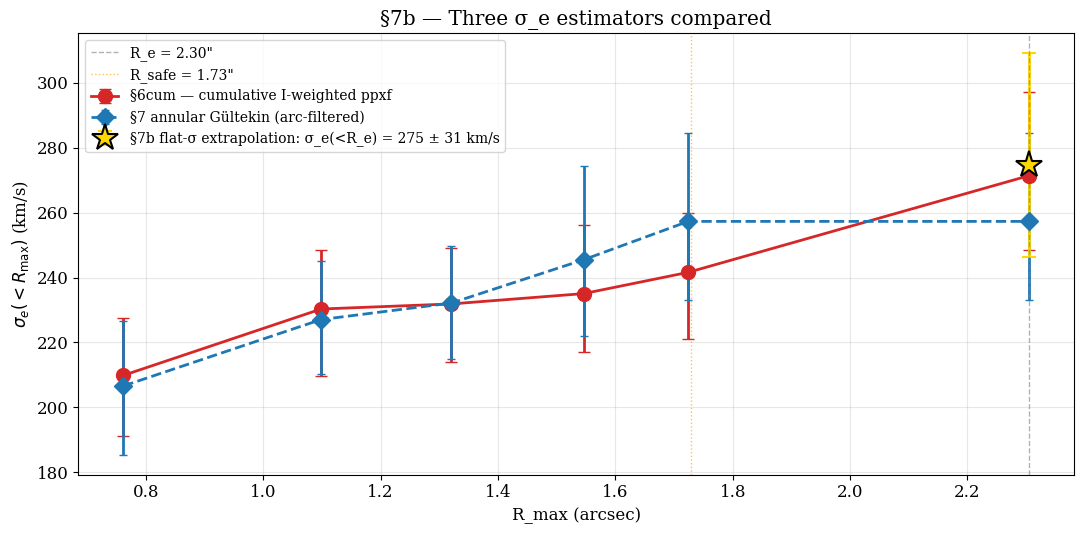


The flat-σ extrapolation value σ_e(<R_e) should fall near
the cumulative ppxf value (271 km/s) since both integrate to R_e.
Difference between methods is a measure of the extrapolation systematic.


In [24]:
# Plot: compare the three σ_e estimators
fig, ax = plt.subplots(figsize=(11, 5.5))

# Cumulative: σ_e at each R_max
r_cum_plot = r_cum
sig_cum = sig_cum_p50
sig_cum_err = [sig_cum_p50 - sig_cum_p16, sig_cum_p84 - sig_cum_p50]
ax.errorbar(r_cum_plot, sig_cum, yerr=sig_cum_err, fmt='o-', ms=10, color='C3',
            capsize=4, lw=2, label='§6cum — cumulative I-weighted ppxf')

# Annular Gültekin filtered
# Use the filtered σ_e value at each R_max from §7
for sps_key in ['combined']:
    if sps_key == 'combined':
        # compute from gultekin dict
        vals = []
        for tag in APERTURES_OF_INTEREST:
            r_max = APERTURES_OF_INTEREST[tag]
            pool = np.concatenate([gultekin[('IFU_band', 'filtered')]['samples'][(sps, tag)][
                np.isfinite(gultekin[('IFU_band', 'filtered')]['samples'][(sps, tag)])]
                                   for sps in SPS_LIBS])
            if len(pool):
                vals.append((r_max, np.percentile(pool, 50),
                             np.percentile(pool, 16), np.percentile(pool, 84)))
        if vals:
            r_a, m_a, lo_a, hi_a = zip(*vals)
            ax.errorbar(r_a, m_a, yerr=[np.array(m_a)-np.array(lo_a), np.array(hi_a)-np.array(m_a)],
                        fmt='D--', ms=9, color='C0', capsize=3, lw=2,
                        label='§7 annular Gültekin (arc-filtered)')

# §7b flat-ext value at R_e
ax.errorbar([R_E], [p50], yerr=[[p50-p16], [p84-p50]], fmt='*', ms=20, color='gold',
            mec='black', mew=1.5, capsize=5, lw=2,
            label=f'§7b flat-σ extrapolation: σ_e(<R_e) = {p50:.0f} ± {(p84-p16)/2:.0f} km/s')

ax.axvline(R_E, color='gray', ls='--', lw=1.0, alpha=0.6, label=f'R_e = {R_E:.2f}"')
ax.axvline(R_SAFE, color='orange', ls=':', lw=1.0, alpha=0.7, label=f'R_safe = {R_SAFE:.2f}"')
ax.set_xlabel('R_max (arcsec)'); ax.set_ylabel(r'$\sigma_e(<R_{\rm max})$ (km/s)')
ax.set_title('§7b — Three σ_e estimators compared')
ax.legend(fontsize=10); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'nb07c_s7b_flat_ext.png'), dpi=150, bbox_inches='tight')
plt.show()

print('\nThe flat-σ extrapolation value σ_e(<R_e) should fall near')
print('the cumulative ppxf value (271 km/s) since both integrate to R_e.')
print('Difference between methods is a measure of the extrapolation systematic.')

## §8. 6-way I(r) cross-source comparison at σ_e(<R_e)

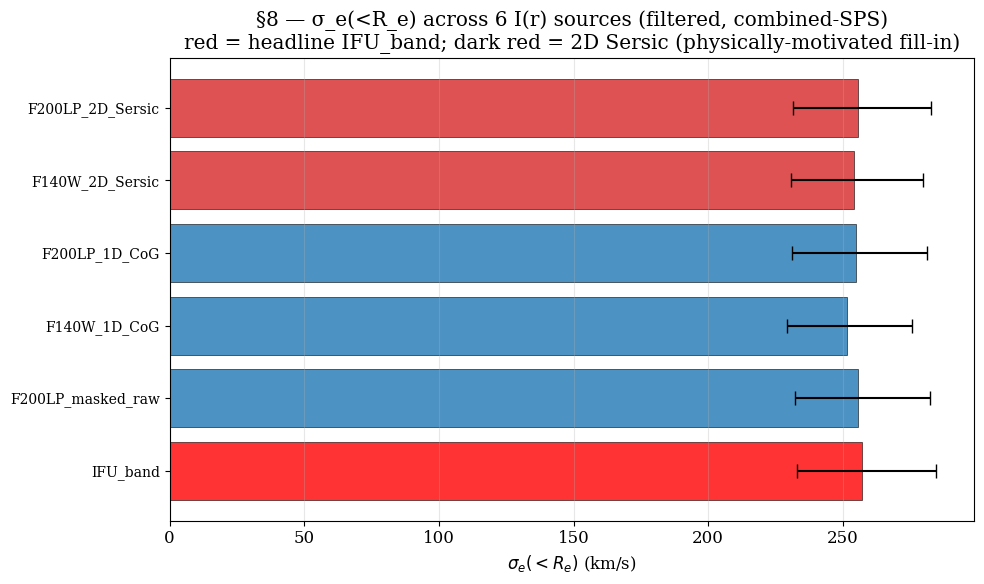


σ_e(<Re) spread across 6 I-sources: min=252, max=257, spread=6 km/s (2%)


In [25]:
# Last (outermost) aperture key — replaces hardcoded 'Re' for patch 4
_APS = list(APERTURES_OF_INTEREST.keys())
LAST_APERTURE = _APS[-1]

fig, ax = plt.subplots(figsize=(10, 6))
src_names = list(I_maps_gultekin.keys())
y_pos = np.arange(len(src_names))
p50_list = []; p16_list = []; p84_list = []
for src in src_names:
    sam = gultekin[(src, 'filtered')]['samples']
    pool = np.concatenate([sam[(s, LAST_APERTURE)][np.isfinite(sam[(s, LAST_APERTURE)])] for s in SPS_LIBS])
    p16, p50, p84 = np.percentile(pool, [16, 50, 84]) if len(pool) else (np.nan,)*3
    p50_list.append(p50); p16_list.append(p16); p84_list.append(p84)
p50_list = np.array(p50_list); p16_list = np.array(p16_list); p84_list = np.array(p84_list)
# Highlight headline (IFU_band) and 2D Sersic (physically-motivated)
colors_b = ['red' if s == 'IFU_band' else ('C3' if '2D_Sersic' in s else 'C0') for s in src_names]
ax.barh(y_pos, p50_list, xerr=[p50_list-p16_list, p84_list-p50_list],
        capsize=5, color=colors_b, alpha=0.8, edgecolor='black', lw=0.5)
ax.set_yticks(y_pos); ax.set_yticklabels(src_names, fontsize=10)
ax.set_xlabel(r'$\sigma_e(<R_e)$ (km/s)')
ax.set_title(f'§8 — σ_e(<R_e) across 6 I(r) sources (filtered, combined-SPS)\n'
             f'red = headline IFU_band; dark red = 2D Sersic (physically-motivated fill-in)')
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'nb07c_s8_isource.png'), dpi=150, bbox_inches='tight')
plt.show()

spread = p50_list.max() - p50_list.min()
print(f'\nσ_e(<Re) spread across 6 I-sources: '
      f'min={p50_list.min():.0f}, max={p50_list.max():.0f}, spread={spread:.0f} km/s '
      f'({100*spread/np.mean(p50_list):.0f}%)')

## §9. Final dashboard + save

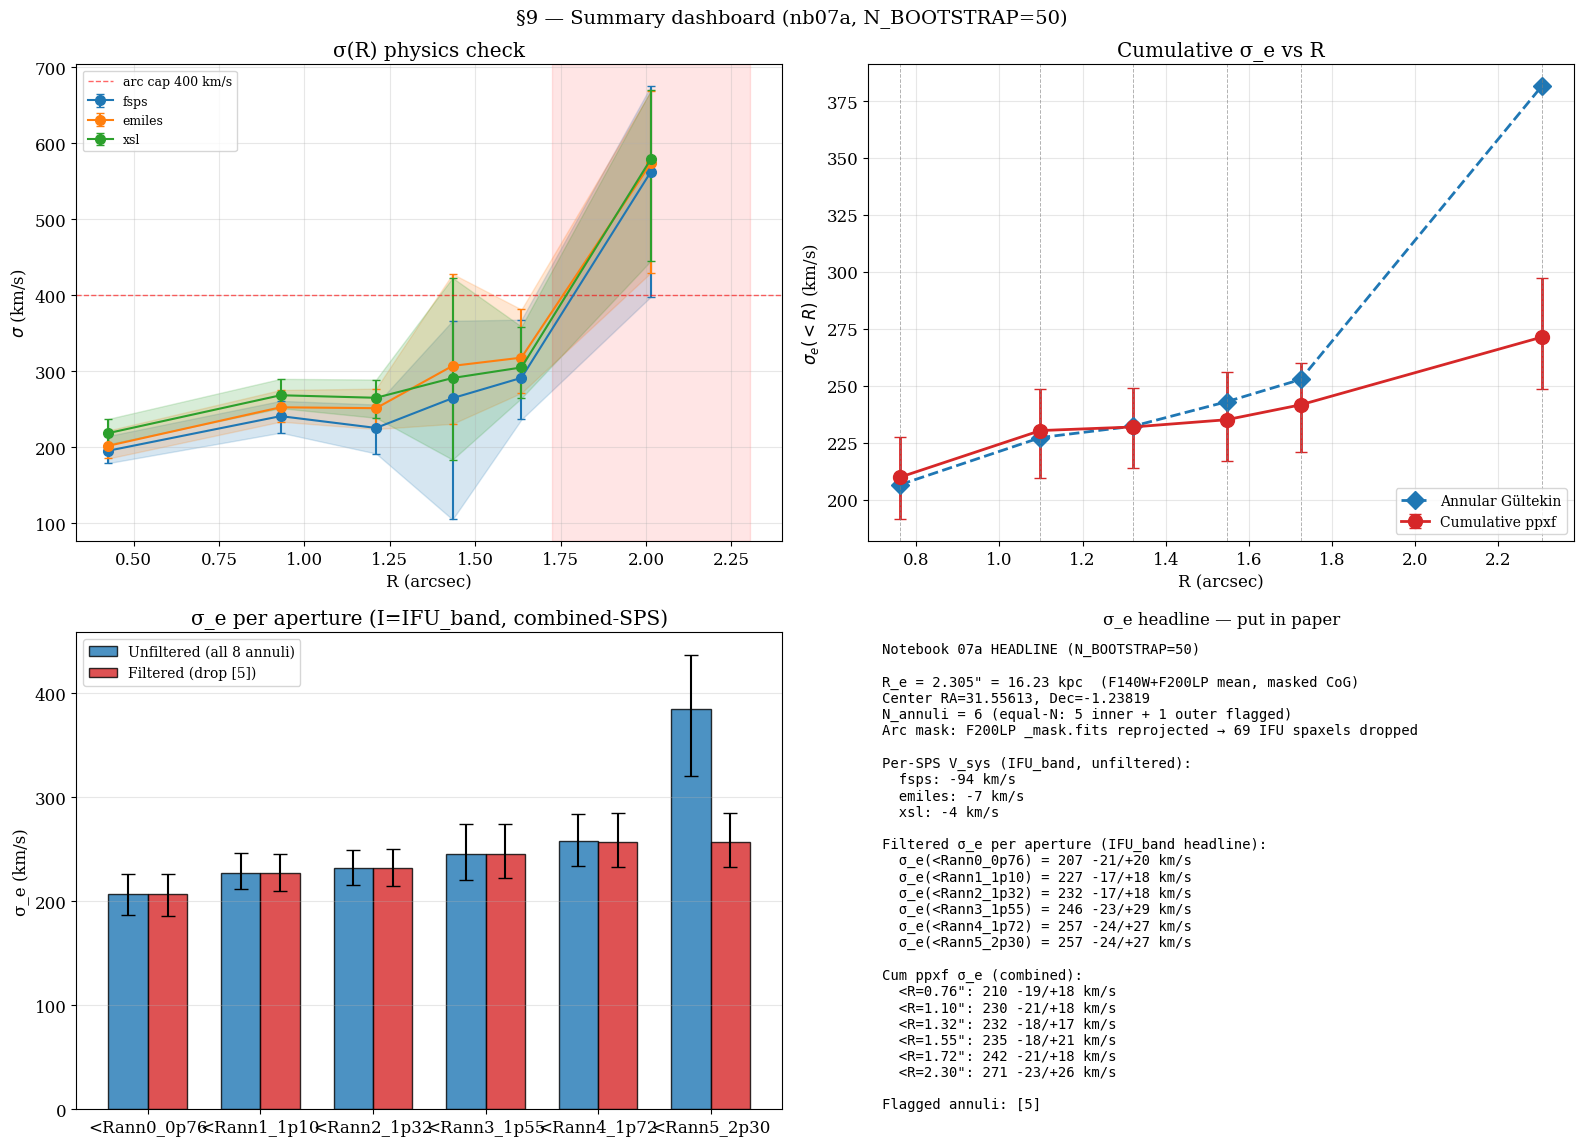

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# (1) σ(R) profile with flags
ax = axes[0, 0]
for sps in SPS_LIBS:
    d = sig_at_ann[sps]
    ax.fill_between(r_mid_ann, d['p16'], d['p84'], color=sps_colors[sps], alpha=0.18)
    ax.errorbar(r_mid_ann, d['p50'], yerr=[d['p50']-d['p16'], d['p84']-d['p50']],
                fmt='o-', ms=7, color=sps_colors[sps], capsize=3, label=sps)
ax.axhline(SIGMA_MAX_CAP, color='red', ls='--', lw=1.0, alpha=0.6, label=f'arc cap {SIGMA_MAX_CAP:.0f} km/s')
for j in FLAGGED_ANNULI:
    ax.axvspan(r_edges[j], r_edges[j+1], color='red', alpha=0.1)
if ann0_seeing_limited:
    ax.axvspan(r_edges[0], r_edges[1], color='orange', alpha=0.08)
ax.set_xlabel('R (arcsec)'); ax.set_ylabel(r'$\sigma$ (km/s)')
ax.set_title('σ(R) physics check'); ax.legend(fontsize=9); ax.grid(alpha=0.3)

# (2) Cumulative σ_e(<R)
ax = axes[0, 1]
ax.errorbar(r_cum, sig_cum_p50, yerr=[sig_cum_p50-sig_cum_p16, sig_cum_p84-sig_cum_p50],
            fmt='o-', ms=10, color='C3', capsize=4, lw=2, label='Cumulative ppxf')
ax.plot(r_cum, sig_ann_p50, 'D--', ms=9, color='C0', lw=2, label='Annular Gültekin')
for tag, rmax in APERTURES_OF_INTEREST.items():
    ax.axvline(rmax, color='gray', ls='--', lw=0.7, alpha=0.6)
ax.set_xlabel('R (arcsec)'); ax.set_ylabel(r'$\sigma_e(<R)$ (km/s)')
ax.set_title('Cumulative σ_e vs R'); ax.legend(fontsize=10); ax.grid(alpha=0.3)

# (3) σ_e per aperture bars (unfiltered vs filtered), headline IFU_band
ax = axes[1, 0]
src_head = 'IFU_band'
tags_p = list(APERTURES_OF_INTEREST.keys())
xpos = np.arange(len(tags_p))
width = 0.35
unf_med, unf_lo, unf_hi = [], [], []
flt_med, flt_lo, flt_hi = [], [], []
for tag in tags_p:
    for mode, ms_lst, lo_lst, hi_lst in [('unfiltered', unf_med, unf_lo, unf_hi),
                                          ('filtered', flt_med, flt_lo, flt_hi)]:
        sam = gultekin[(src_head, mode)]['samples']
        pool = np.concatenate([sam[(s, tag)][np.isfinite(sam[(s, tag)])] for s in SPS_LIBS])
        p16, p50, p84 = np.percentile(pool, [16, 50, 84]) if len(pool) else (np.nan,)*3
        ms_lst.append(p50); lo_lst.append(p16); hi_lst.append(p84)
unf_med, unf_lo, unf_hi = map(np.array, (unf_med, unf_lo, unf_hi))
flt_med, flt_lo, flt_hi = map(np.array, (flt_med, flt_lo, flt_hi))
ax.bar(xpos-width/2, unf_med, width, yerr=[unf_med-unf_lo, unf_hi-unf_med], capsize=5,
       color='C0', alpha=0.8, label='Unfiltered (all 8 annuli)', edgecolor='black')
ax.bar(xpos+width/2, flt_med, width, yerr=[flt_med-flt_lo, flt_hi-flt_med], capsize=5,
       color='C3', alpha=0.8, label=f'Filtered (drop {FLAGGED_ANNULI})', edgecolor='black')
ax.set_xticks(xpos); ax.set_xticklabels(['<'+t for t in tags_p])
ax.set_ylabel(r'σ_e (km/s)')
ax.set_title(f'σ_e per aperture (I={src_head}, combined-SPS)')
ax.legend(fontsize=10); ax.grid(alpha=0.3, axis='y')

# (4) Text panel — headline
ax = axes[1, 1]; ax.axis('off')
txt = f'Notebook 07a HEADLINE (N_BOOTSTRAP={N_BOOTSTRAP})\n\n'
txt += f'R_e = {R_E:.3f}" = {R_E*KPC_PER_ARCSEC:.2f} kpc  (F140W+F200LP mean, masked CoG)\n'
txt += f'Center RA={RA_CENTER:.5f}, Dec={DEC_CENTER:.5f}\n'
txt += f'N_annuli = {n_ann} (equal-N: {N_INNER} inner + 1 outer flagged)\n'
txt += f'Arc mask: F200LP _mask.fits reprojected → {arc_spax_mask.sum()} IFU spaxels dropped\n\n'
txt += f'Per-SPS V_sys (IFU_band, unfiltered):\n'
for sps, V in gultekin[('IFU_band', 'unfiltered')]['V_offsets'].items():
    txt += f'  {sps}: {V:+.0f} km/s\n'
txt += f'\nFiltered σ_e per aperture (IFU_band headline):\n'
for i, tag in enumerate(tags_p):
    txt += f'  σ_e(<{tag}) = {flt_med[i]:.0f} -{flt_med[i]-flt_lo[i]:.0f}/+{flt_hi[i]-flt_med[i]:.0f} km/s\n'
txt += f'\nCum ppxf σ_e (combined):\n'
for i, r_max in enumerate(r_cum):
    txt += f'  <R={r_max:.2f}": {sig_cum_p50[i]:.0f} -{sig_cum_p50[i]-sig_cum_p16[i]:.0f}/+{sig_cum_p84[i]-sig_cum_p50[i]:.0f} km/s\n'
txt += f'\nFlagged annuli: {FLAGGED_ANNULI}'
ax.text(0.02, 0.98, txt, transform=ax.transAxes, va='top', ha='left',
        family='monospace', fontsize=10)
ax.set_title('σ_e headline — put in paper', fontsize=12)

fig.suptitle(f'§9 — Summary dashboard (nb07a, N_BOOTSTRAP={N_BOOTSTRAP})', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'nb07c_s9_dashboard.png'), dpi=160, bbox_inches='tight')
plt.show()

In [27]:
save_dict = {}
# Per-I-source per-SPS posteriors + combined
for src_name in I_maps_gultekin:
    safe = src_name.replace(' ', '_').replace('(', '').replace(')', '').replace('/', '_')
    for mode in ['unfiltered', 'filtered']:
        sam = gultekin[(src_name, mode)]['samples']
        for sps in SPS_LIBS:
            for tag in APERTURES_OF_INTEREST:
                s = sam[(sps, tag)][np.isfinite(sam[(sps, tag)])]
                if len(s):
                    save_dict[f'{safe}_{mode}_{sps}_{tag}_p50'] = float(np.percentile(s, 50))
                    save_dict[f'{safe}_{mode}_{sps}_{tag}_p16'] = float(np.percentile(s, 16))
                    save_dict[f'{safe}_{mode}_{sps}_{tag}_p84'] = float(np.percentile(s, 84))
        # combined
        for tag in APERTURES_OF_INTEREST:
            pool = np.concatenate([sam[(s, tag)][np.isfinite(sam[(s, tag)])] for s in SPS_LIBS])
            if len(pool):
                save_dict[f'{safe}_{mode}_combined_{tag}_p50'] = float(np.percentile(pool, 50))
                save_dict[f'{safe}_{mode}_combined_{tag}_p16'] = float(np.percentile(pool, 16))
                save_dict[f'{safe}_{mode}_combined_{tag}_p84'] = float(np.percentile(pool, 84))
                save_dict[f'{safe}_{mode}_combined_{tag}_samples'] = pool
    # V offsets
    for sps, V in gultekin[(src_name, 'unfiltered')]['V_offsets'].items():
        save_dict[f'{safe}_V_offset_{sps}'] = V

# Cumulative per-SPS + combined
for j, a in enumerate(cum_apertures):
    r_tag = f'cumR_{a["r_max"]:.3f}'.replace('.', 'p')
    for sps in SPS_LIBS:
        samp = cum_bootstrap[(j, sps)]['sig_boot'].ravel()
        samp = samp[np.isfinite(samp)]
        if len(samp):
            save_dict[f'cum_{sps}_{r_tag}_p50'] = float(np.percentile(samp, 50))
            save_dict[f'cum_{sps}_{r_tag}_p16'] = float(np.percentile(samp, 16))
            save_dict[f'cum_{sps}_{r_tag}_p84'] = float(np.percentile(samp, 84))
    pool = np.concatenate([cum_bootstrap[(j, sps)]['sig_boot'].ravel() for sps in SPS_LIBS])
    pool = pool[np.isfinite(pool)]
    if len(pool):
        save_dict[f'cum_combined_{r_tag}_p50'] = float(np.percentile(pool, 50))
        save_dict[f'cum_combined_{r_tag}_p16'] = float(np.percentile(pool, 16))
        save_dict[f'cum_combined_{r_tag}_p84'] = float(np.percentile(pool, 84))
        save_dict[f'cum_combined_{r_tag}_samples'] = pool

# Metadata
save_dict['R_e_arcsec'] = R_E; save_dict['R_e_kpc'] = R_E*KPC_PER_ARCSEC
save_dict['Re_F140W'] = Re_f140; save_dict['Re_F200LP'] = Re_f200; save_dict['Re_IFU_band'] = Re_ifu
save_dict['center_ra'] = RA_CENTER; save_dict['center_dec'] = DEC_CENTER
save_dict['n_bootstrap'] = N_BOOTSTRAP; save_dict['n_mc'] = N_MC
save_dict['n_annuli'] = n_ann
save_dict['n_inner'] = N_INNER
save_dict['r_safe_arcsec'] = R_SAFE
save_dict['z_systemic'] = Z_SYSTEMIC
save_dict['r_edges'] = r_edges
save_dict['flagged_annuli'] = np.array(FLAGGED_ANNULI)
save_dict['method'] = 'radial_annular_Gultekin_v07c_equalN'
save_dict['arc_mask_source'] = 'F200LP_mask_fits_reprojected_nearest'

out_path = os.path.join(RESULTS_DIR, 'sigma_e_radial_07c.npz')
np.savez(out_path, **save_dict)
print(f'Saved: {out_path}')
print(f'  {len(save_dict)} keys')

Saved: ../results/sigma_e_radial_07c.npz
  1049 keys
